# The Kalman Filter, one matrix at a time

This notebook builds the Kalman filter **from linear algebra only** — no probability
machinery beyond "a Gaussian is a mean vector plus a covariance matrix".

Everything a Kalman filter does is one of exactly **two** operations on a Gaussian:

| operation | linear algebra | what it does to the ellipse |
|---|---|---|
| **predict** | congruence $P \mapsto FPF^{\mathsf T} + Q$ | maps + inflates it |
| **update** | Schur complement of a block matrix | shrinks it, in one direction |

That is the whole filter. The rest of this notebook is unpacking those two rows.

### Contents

0. Setup and helpers
1. **A covariance is a quadratic form** — $P = V\Lambda V^{\mathsf T} = AA^{\mathsf T}$, and the ellipse it draws
2. **Operation 1: push a Gaussian through a matrix** — why $FPF^{\mathsf T}$, and what $+Q$ does
3. **Operation 2: conditioning = Schur complement** — where the Kalman gain actually comes from
4. **Assembling the filter** — a 12-line implementation, plus why $K$ is *optimal* (a parabola)
5. **Four faces of the same update** — information form / least squares / projection / square root
6. **The geometry of one update** (interactive) — why measuring an angle corrects the angular velocity
7. **A full filter run** — knee flexion angle, consistency checks, the Riccati equation, $\rho(A_{cl})$
8. **Observability** — the linear-algebra reason some states never get corrected
9. **Cheat sheet, exercises, and the bridge to the EKF**

Run the cells in order — later sections reuse helpers defined earlier.

---
## 0. Setup

Needs `numpy`, `scipy`, `matplotlib`, and `ipywidgets` for the sliders
(`pip install ipywidgets`). If `ipywidgets` is missing, every `@interact` cell still executes
once with its default values, so nothing breaks — you just lose the sliders.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import (inv, cholesky, eigh, svd, matrix_rank,
                          solve, lstsq, qr, det, norm, cond, matrix_power)
from IPython.display import display, Math

np.set_printoptions(precision=3, suppress=True, linewidth=120)
rng = np.random.default_rng(7)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110, "font.size": 9})

try:
    from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Dropdown
    HAVE_WIDGETS = True
except Exception:                      # graceful fallback: run once with defaults
    HAVE_WIDGETS = False
    class _Static:
        def __init__(self, value=None, options=None, **kw):
            self.value = value if value is not None else (options[0] if options else None)
    FloatSlider = IntSlider = Checkbox = Dropdown = _Static
    def interact(_f=None, **kw):
        def run(f):
            f(**{k: getattr(v, "value", v) for k, v in kw.items()})
            return f
        return run if _f is None else run(_f)

print(f"numpy {np.__version__}  |  interactive sliders: {HAVE_WIDGETS}")

numpy 2.4.6  |  interactive sliders: False


In [3]:
# ---------- helpers used everywhere below ----------------------------------

def sym(P):
    """Force exact symmetry. Floating point makes P drift asymmetric; this is free insurance."""
    return 0.5 * (P + P.T)

def bmat_tex(M, fmt="{:.3g}"):
    M = np.atleast_2d(np.asarray(M, float))
    return (r"\begin{bmatrix}"
            + r"\\".join(" & ".join(fmt.format(v) for v in row) for row in M)
            + r"\end{bmatrix}")

def show(*pairs, fmt="{:.3g}"):
    """show('P', P, 'K', K)  ->  renders   P = [..]    K = [..]   as real LaTeX."""
    display(Math(r"\qquad ".join(f"{lab} = {bmat_tex(M, fmt)}"
                                 for lab, M in zip(pairs[0::2], pairs[1::2]))))

def ellipse_points(mean, P, n_std=2.0, num=200):
    """Points on the n_std-sigma contour of N(mean, P).

    P = V diag(w) V^T          (eigh -- P is symmetric)
    A = V diag(sqrt(w))        satisfies  A A^T = P
    contour = mean + n_std * A @ (unit circle)      <-- that is the whole idea
    """
    mean = np.asarray(mean, float).ravel()
    w, V = eigh(np.asarray(P, float))
    A = V @ np.diag(np.sqrt(np.maximum(w, 0.0)))
    t = np.linspace(0, 2*np.pi, num)
    return mean[:, None] + n_std * A @ np.vstack([np.cos(t), np.sin(t)])

def plot_ellipse(ax, mean, P, n_std=2.0, label=None, color="C0",
                 ls="-", lw=2, alpha=1.0, fill=False, dot=True):
    xy = ellipse_points(mean, P, n_std)
    ax.plot(xy[0], xy[1], ls, color=color, lw=lw, label=label, alpha=alpha)
    if fill:
        ax.fill(xy[0], xy[1], color=color, alpha=0.12)
    if dot:
        m = np.asarray(mean, float).ravel()
        ax.plot([m[0]], [m[1]], "o", color=color, ms=5, alpha=alpha)

def cov_from(sx, sy, rho):
    """2x2 covariance from two standard deviations and a correlation."""
    return np.array([[sx*sx, rho*sx*sy],
                     [rho*sx*sy, sy*sy]])

def orient(V):
    """Eigenvector SIGNS are arbitrary: if v is an eigenvector so is -v, and eigh
    picks one at random. Flip each column so its largest component is positive --
    purely cosmetic, so the drawn arrows point along the visible lobe of the ellipse."""
    s = np.sign(V[np.argmax(np.abs(V), axis=0), np.arange(V.shape[1])])
    return V * np.where(s == 0, 1.0, s)

def axes_equal(ax, lim=None):
    ax.set_aspect("equal")
    ax.axhline(0, lw=.5, c="k", alpha=.4); ax.axvline(0, lw=.5, c="k", alpha=.4)
    if lim: ax.set_xlim(*lim); ax.set_ylim(*lim)

print("helpers ready")

helpers ready


---
## 1. A covariance is a quadratic form

A Gaussian in $\mathbb R^n$ is a pair: a mean $\mu \in \mathbb R^n$ and a covariance

$$P = \mathbb E\big[(x-\mu)(x-\mu)^{\mathsf T}\big] \in \mathbb R^{n\times n},
\qquad P = P^{\mathsf T},\quad P \succeq 0 .$$

$P$ is symmetric because $(ab^{\mathsf T})^{\mathsf T} = ba^{\mathsf T}$, and positive semidefinite because
for any direction $u$,

$$u^{\mathsf T} P u = \mathbb E\big[(u^{\mathsf T}(x-\mu))^2\big] \;=\; \operatorname{Var}\big(u^{\mathsf T}x\big) \;\ge\; 0 .$$

**That last identity is the one to memorise: $u^{\mathsf T}Pu$ is the variance you see when you look at the state along direction $u$.**
A covariance matrix is not "a table of numbers"; it is a *function that answers the question "how uncertain am I in this direction?"* for every direction at once.

### The ellipse

Contours of constant probability are the level sets of the Mahalanobis quadratic form

$$\|x-\mu\|^2_{P^{-1}} \;=\; (x-\mu)^{\mathsf T} P^{-1} (x-\mu) \;=\; c^2 ,$$

which are ellipsoids. Where are their axes? Use the spectral theorem — $P$ is symmetric, so

$$P = V\Lambda V^{\mathsf T},\qquad V^{\mathsf T}V = I,\qquad \Lambda = \operatorname{diag}(\lambda_1,\dots,\lambda_n)\succeq 0 .$$

* **columns of $V$** = principal axes of the ellipse
* **$\sqrt{\lambda_i}$** = the $1\sigma$ half-length along axis $i$ (a *standard deviation*, hence the square root)
* $\det P = \prod \lambda_i$ = squared "volume" of uncertainty

Define $A = V\Lambda^{1/2}$. Then $AA^{\mathsf T} = V\Lambda V^{\mathsf T} = P$, and

$$\boxed{\;\text{the } 1\sigma \text{ ellipse } = A \cdot (\text{unit sphere})\;}$$

So **every covariance matrix is just the unit ball pushed through some matrix $A$.** Keep that
sentence; the entire filter is bookkeeping about what happens to $A$.

(The Cholesky factor $L$ with $LL^{\mathsf T}=P$ is a *different* $A$ giving the *same* ellipse —
$A$ is only defined up to right-multiplication by an orthogonal matrix, since $(AQ)(AQ)^{\mathsf T}=AA^{\mathsf T}$.
Square-root filters in §5.4 exploit exactly this freedom.)

In [4]:
sx, sy, rho = 2.0, 1.0, 0.7
P1 = cov_from(sx, sy, rho)

w, V = eigh(P1)                    # P1 = V diag(w) V^T ,  w ascending
A    = V @ np.diag(np.sqrt(w))     # A A^T = P1

show("P", P1, "V", V, r"\Lambda", np.diag(w))

print("V orthogonal?            ", np.allclose(V.T @ V, np.eye(2)))
print("A A^T == P?              ", np.allclose(A @ A.T, P1))
print("eigenvalues (variances along principal axes):", w)
print("1-sigma half-axis lengths (sqrt of those)   :", np.sqrt(w))
print("det P = prod(eigenvalues)?", np.isclose(det(P1), w.prod()))

# The Cholesky factor is a *different* A giving the *same* ellipse:
L = cholesky(P1)
print("\nL L^T == P?              ", np.allclose(L @ L.T, P1))
print("but L != V Lambda^1/2:\n", L, "\n", A)
print("they differ by an orthogonal factor:  A^-1 L is orthogonal?",
      np.allclose((inv(A) @ L) @ (inv(A) @ L).T, np.eye(2)))

<IPython.core.display.Math object>

V orthogonal?             True
A A^T == P?               True
eigenvalues (variances along principal axes): [0.448 4.552]
1-sigma half-axis lengths (sqrt of those)   : [0.669 2.134]
det P = prod(eigenvalues)? True

L L^T == P?               True
but L != V Lambda^1/2:
 [[2.    0.   ]
 [0.7   0.714]] 
 [[ 0.245 -1.985]
 [-0.623 -0.782]]
they differ by an orthogonal factor:  A^-1 L is orthogonal? True


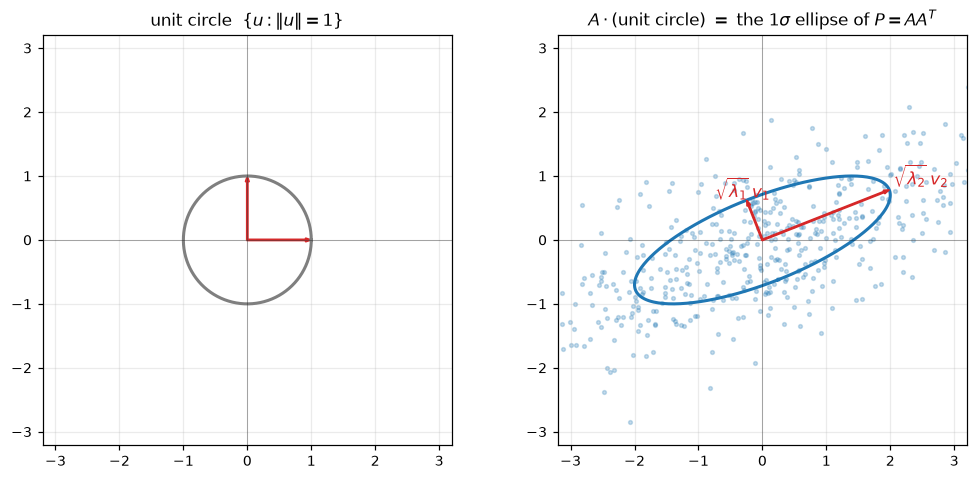

empirical covariance of A @ (standard normals):
 [[3.987 1.395]
 [1.395 0.997]]
P:
 [[4.  1.4]
 [1.4 1. ]]


In [5]:
# The unit circle, and the same circle pushed through A.
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
t    = np.linspace(0, 2*np.pi, 300)
circ = np.vstack([np.cos(t), np.sin(t)])

axes[0].plot(circ[0], circ[1], color="C7", lw=2)
for k in range(2):
    axes[0].arrow(0, 0, *np.eye(2)[:, k], color="C3", width=.02, length_includes_head=True)
axes[0].set_title(r"unit circle  $\{u:\|u\|=1\}$")
axes_equal(axes[0], (-3.2, 3.2))

E  = A @ circ
Vo = orient(V)                     # cosmetic sign flip only -- see helper
pts = rng.multivariate_normal([0, 0], P1, 500)
axes[1].scatter(pts[:, 0], pts[:, 1], s=6, alpha=.25, color="C0")
axes[1].plot(E[0], E[1], color="C0", lw=2)
for k in range(2):
    axes[1].arrow(0, 0, *(np.sqrt(w[k]) * Vo[:, k]), color="C3", width=.02,
                  length_includes_head=True, zorder=5)
    axes[1].annotate(rf"$\sqrt{{\lambda_{k+1}}}\,v_{{{k+1}}}$",
                     1.25*np.sqrt(w[k])*Vo[:, k], color="C3", fontsize=11,
                     ha="center", va="center")
axes[1].set_title(r"$A\cdot$(unit circle) $=$ the $1\sigma$ ellipse of $P=AA^T$")
axes_equal(axes[1], (-3.2, 3.2))
plt.tight_layout(); plt.show()

# 500 dots are for the eye; use many more for the numeric check.
big = A @ rng.standard_normal((2, 200_000))    # push standard normals through A
print("empirical covariance of A @ (standard normals):\n", np.cov(big))
print("P:\n", P1)

### Play with it

Watch three things as you move the sliders:

* **$\rho \to \pm 1$**: the ellipse flattens onto a line, $\lambda_{\min}\to 0$, $\det P \to 0$.
  A singular $P$ means the two components are *linearly dependent* — the state really lives in
  a 1-D subspace, and $P^{-1}$ does not exist. Filters die here; §5.4 explains the fix.
* **$\rho = 0$**: the axes align with the coordinate axes, and $V = I$.
* The ellipse's tilt is a property of the **eigenvectors**, not of $\sigma_x,\sigma_y$ alone.

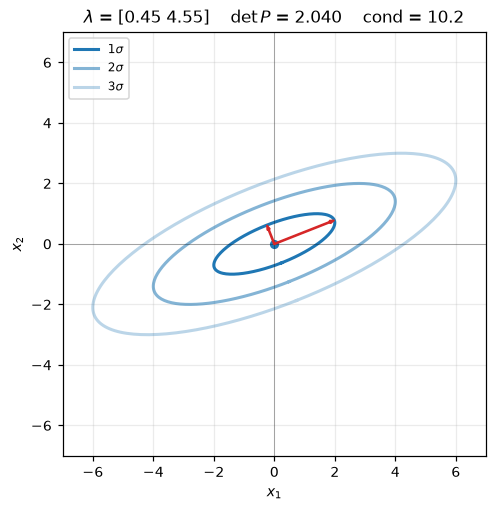

In [6]:
@interact(sigma_x=FloatSlider(value=2.0, min=0.2, max=4.0, step=0.1),
          sigma_y=FloatSlider(value=1.0, min=0.2, max=4.0, step=0.1),
          rho    =FloatSlider(value=0.7, min=-0.98, max=0.98, step=0.02))
def _covariance_explorer(sigma_x, sigma_y, rho):
    P = cov_from(sigma_x, sigma_y, rho)
    w, V = eigh(P)
    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    for n, a in zip([1, 2, 3], [1.0, .55, .3]):
        plot_ellipse(ax, [0, 0], P, n_std=n, color="C0", alpha=a,
                     label=f"${n}\\sigma$", dot=(n == 1))
    Vo = orient(V)
    for k in range(2):
        ax.arrow(0, 0, *(np.sqrt(w[k])*Vo[:, k]), color="C3", width=.035,
                 length_includes_head=True, zorder=5)
    axes_equal(ax, (-7, 7)); ax.legend(loc="upper left", fontsize=8)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(f"$\\lambda$ = {np.round(w,2)}    $\\det P$ = {det(P):.3f}    "
                 f"cond = {cond(P):.1f}")
    plt.show()

---
## 2. Operation 1 — push a Gaussian through a matrix

Let $x\sim\mathcal N(\mu,P)$ and $y = Fx$. Then $\mu_y = F\mu$ by linearity, and

$$P_y=\mathbb E\big[(Fx-F\mu)(Fx-F\mu)^{\mathsf T}\big]
     =\mathbb E\big[F(x-\mu)(x-\mu)^{\mathsf T}F^{\mathsf T}\big]
     =F\,\mathbb E\big[(x-\mu)(x-\mu)^{\mathsf T}\big]\,F^{\mathsf T}
     =\boxed{FPF^{\mathsf T}} .$$

Three lines, and it is the entire prediction step. Things worth noticing:

**It is a congruence, not a similarity.** $FPF^{\mathsf T}$, not $FPF^{-1}$. Congruence is the
transformation that preserves the *quadratic form* structure: symmetry survives
($(FPF^{\mathsf T})^{\mathsf T} = FPF^{\mathsf T}$) and so does positive semidefiniteness,

$$u^{\mathsf T}(FPF^{\mathsf T})u = (F^{\mathsf T}u)^{\mathsf T}P(F^{\mathsf T}u)\ \ge\ 0 .$$

Sylvester's law of inertia says congruence preserves the *number* of positive/zero/negative
eigenvalues (when $F$ is invertible) — the covariance stays a covariance, always.

**It is exactly "map the ellipse".** If $P = AA^{\mathsf T}$ then
$FPF^{\mathsf T} = (FA)(FA)^{\mathsf T}$. So the new $A$ is $FA$: the new ellipse is the old
ellipse with $F$ applied to it, point by point. Nothing more.

**Volume scales by $|\det F|$**: $\det(FPF^{\mathsf T}) = (\det F)^2 \det P$. If $F$ is
singular, the ellipse collapses onto $\operatorname{col}(F)$ and $P$ becomes singular.

**Adding independent noise adds covariances.** With $y = Fx + w$, $w\sim\mathcal N(0,Q)$
independent of $x$, the cross terms $\mathbb E[(x-\mu)w^{\mathsf T}]$ vanish and

$$P_y = FPF^{\mathsf T} + Q .$$

Uncertainty only ever *grows* in the predict step: $u^{\mathsf T}(FPF^{\mathsf T}+Q)u \ge u^{\mathsf T}FPF^{\mathsf T}u$
for every $u$, since $Q\succeq 0$.

In [7]:
F2 = np.array([[1.0, 1.0],      # constant-velocity step with dt = 1:
               [0.0, 1.0]])     #   position += velocity, velocity unchanged
P2 = cov_from(2.0, 1.0, 0.0)    # start uncorrelated
P2p = F2 @ P2 @ F2.T

show("F", F2, "P", P2, "FPF^T", P2p)

w2, V2 = eigh(P2); A2 = V2 @ np.diag(np.sqrt(w2))
print("(FA)(FA)^T == F P F^T ?      ", np.allclose((F2 @ A2) @ (F2 @ A2).T, P2p))
print("symmetric ?                  ", np.allclose(P2p, P2p.T))
print("eigenvalues still >= 0 ?     ", eigh(P2p)[0])
print("det(FPF^T) == det(F)^2 det(P)?",
      np.isclose(det(P2p), det(F2)**2 * det(P2)))

# Monte-Carlo confirmation -- no formula, just samples.
X = rng.multivariate_normal([0, 0], P2, 200_000).T     # 2 x N
Y = F2 @ X
print("\nempirical cov of F x:\n", np.cov(Y))
print("F P F^T:\n", P2p)

<IPython.core.display.Math object>

(FA)(FA)^T == F P F^T ?       True
symmetric ?                   True
eigenvalues still >= 0 ?      [0.764 5.236]
det(FPF^T) == det(F)^2 det(P)? True

empirical cov of F x:
 [[5.005 0.994]
 [0.994 0.998]]
F P F^T:
 [[5. 1.]
 [1. 1.]]


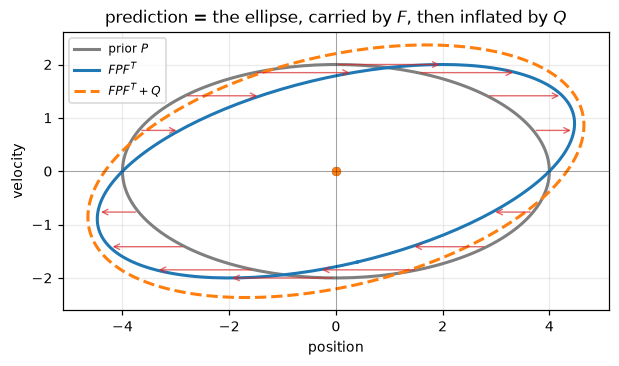

In [8]:
# Watch the ellipse get carried by F, point by point.
fig, ax = plt.subplots(figsize=(6.4, 5.0))
plot_ellipse(ax, [0, 0], P2,  color="C7", label="prior $P$")
plot_ellipse(ax, [0, 0], P2p, color="C0", label="$FPF^T$")
plot_ellipse(ax, [0, 0], P2p + 0.4*np.eye(2), color="C1", ls="--",
             label="$FPF^T+Q$")

# a handful of points on the prior ellipse and where F sends them
E0 = ellipse_points([0, 0], P2, 2.0, num=17)
E1 = F2 @ E0
for k in range(E0.shape[1] - 1):
    ax.annotate("", xy=E1[:, k], xytext=E0[:, k],
                arrowprops=dict(arrowstyle="->", color="C3", lw=.9, alpha=.7))
axes_equal(ax); ax.legend(fontsize=8)
ax.set_xlabel("position"); ax.set_ylabel("velocity")
ax.set_title(r"prediction = the ellipse, carried by $F$, then inflated by $Q$")
plt.show()

Notice the shear: after one constant-velocity step, position and velocity are **correlated**,
even though they started independent. That correlation is not a nuisance — it is precisely what
lets a *position* measurement later fix the *velocity* (§6).

### Play with $F$

Try:

* $f_{12}\neq 0$ — the shear that couples velocity into position;
* $\det F = 0$ (e.g. $F = \begin{smallmatrix}1&1\\1&1\end{smallmatrix}$) — the ellipse collapses to a segment, `rank` drops to 1;
* $F = cI$ — pure scaling, eigenvalues scale by $c^2$;
* a rotation $\begin{smallmatrix}\cos\theta&-\sin\theta\\ \sin\theta&\cos\theta\end{smallmatrix}$ — the ellipse turns but $\det$ and eigenvalues are unchanged (orthogonal congruence = similarity).

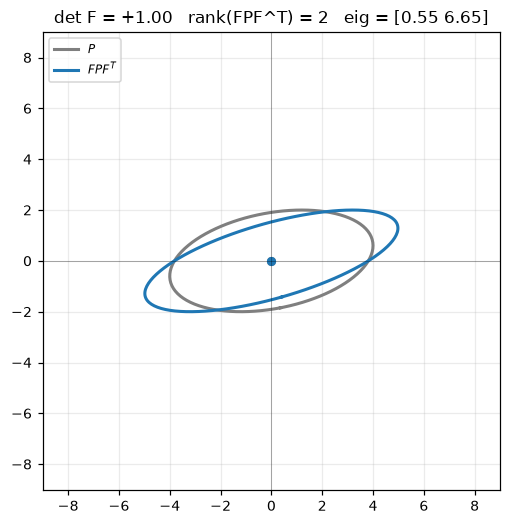

In [9]:
@interact(f11=FloatSlider(value=1.0, min=-2, max=2, step=0.1),
          f12=FloatSlider(value=1.0, min=-2, max=2, step=0.1),
          f21=FloatSlider(value=0.0, min=-2, max=2, step=0.1),
          f22=FloatSlider(value=1.0, min=-2, max=2, step=0.1),
          q  =FloatSlider(value=0.0, min=0.0, max=2, step=0.05))
def _congruence_explorer(f11, f12, f21, f22, q):
    F = np.array([[f11, f12], [f21, f22]])
    P = cov_from(2.0, 1.0, 0.3)
    Pp = F @ P @ F.T
    Pq = Pp + q*np.eye(2)
    fig, ax = plt.subplots(figsize=(5.4, 5.4))
    plot_ellipse(ax, [0, 0], P,  color="C7", label="$P$")
    plot_ellipse(ax, [0, 0], Pp, color="C0", label="$FPF^T$")
    if q > 0:
        plot_ellipse(ax, [0, 0], Pq, color="C1", ls="--", label="$FPF^T+qI$")
    axes_equal(ax, (-9, 9)); ax.legend(loc="upper left", fontsize=8)
    ax.set_title(f"det F = {det(F):+.2f}   rank(FPF^T) = {matrix_rank(Pp)}   "
                 f"eig = {np.round(eigh(Pq)[0], 2)}")
    plt.show()

### What $+Q$ does, spectrally

For isotropic process noise $Q = qI$ the effect is exactly readable off the eigenvalues:

$$P + qI = V\Lambda V^{\mathsf T} + qVV^{\mathsf T} = V(\Lambda + qI)V^{\mathsf T} .$$

Same eigenvectors, every eigenvalue shifted by $+q$. So isotropic noise **rounds the ellipse out**
(the ratio $\lambda_{\max}/\lambda_{\min}$ moves toward 1) and pushes $P$ away from singularity —
it is a Tikhonov regulariser. General $Q$ does the same job anisotropically: it injects uncertainty
along $\operatorname{col}(Q)$ only.

In [10]:
P_ = cov_from(3.0, 0.5, 0.8)
for q in [0.0, 0.5, 2.0]:
    w_, _ = eigh(P_ + q*np.eye(2))
    print(f"q = {q:4.1f}   eig = {np.round(w_,3)}   cond = {w_.max()/w_.min():7.2f}")
print("\neigenvectors are unchanged by q*I:")
print(eigh(P_)[1], "\n", eigh(P_ + 2*np.eye(2))[1])

q =  0.0   eig = [0.088 9.162]   cond =  103.62
q =  0.5   eig = [0.588 9.662]   cond =   16.42
q =  2.0   eig = [ 2.088 11.162]   cond =    5.34

eigenvectors are unchanged by q*I:
[[ 0.133 -0.991]
 [-0.991 -0.133]] 
 [[ 0.133 -0.991]
 [-0.991 -0.133]]


---
## 3. Operation 2 — conditioning is a Schur complement

This is the only genuinely new linear algebra in the Kalman filter, and it is where the gain $K$
is born. Set it up as a **joint** Gaussian and everything falls out mechanically.

Prior $x\sim\mathcal N(\mu, P)$ in $\mathbb R^n$. Measurement model
$$z = Hx + v,\qquad v\sim\mathcal N(0,R)\ \text{independent of } x,\qquad H\in\mathbb R^{m\times n}.$$

Compute the three blocks of the joint covariance of the stacked vector $\begin{bmatrix}x\\z\end{bmatrix}$:

$$\operatorname{Cov}(x) = P,$$
$$\operatorname{Cov}(x,z)=\mathbb E\big[(x-\mu)(Hx+v-H\mu)^{\mathsf T}\big]
   =\mathbb E\big[(x-\mu)(x-\mu)^{\mathsf T}\big]H^{\mathsf T} + \underbrace{\mathbb E[(x-\mu)v^{\mathsf T}]}_{=0}
   = PH^{\mathsf T},$$
$$\operatorname{Cov}(z)=HPH^{\mathsf T}+R \;=:\; S .$$

So
$$\begin{bmatrix}x\\z\end{bmatrix}\sim\mathcal N\left(
\begin{bmatrix}\mu\\ H\mu\end{bmatrix},\;
M=\begin{bmatrix}P & PH^{\mathsf T}\\ HP & S\end{bmatrix}\right).$$

### Decorrelating the blocks — where $K$ comes from

We want $x$ given $z$. The trick is pure linear algebra: **find the matrix $K$ that makes
$x - Kz$ uncorrelated with $z$.** Then, for jointly Gaussian variables, uncorrelated $\Rightarrow$
independent, so observing $z$ tells us nothing about $x-Kz$, and we can read the answer off.

$$\operatorname{Cov}(x - Kz,\; z) = PH^{\mathsf T} - KS \stackrel{!}{=} 0
\quad\Longrightarrow\quad \boxed{K = PH^{\mathsf T}S^{-1}}$$

That is the **Kalman gain**, and it appeared with no probability at all — it is the coefficient of a
one-step Gram–Schmidt, projecting $x$ onto $z$ in the inner product $\langle a,b\rangle = \mathbb E[ab^{\mathsf T}]$.

The residual covariance follows immediately:
$$\operatorname{Cov}(x-Kz) = P - KS K^{\mathsf T}\ =\ P - PH^{\mathsf T}S^{-1}HP\ =:\ P^+ .$$

$P^+$ is the **Schur complement** of the block $S$ in $M$, usually written $M/S$. Writing
$x = (x - Kz) + Kz$ with the two terms independent then gives the conditional law directly:

$$x\mid z \;\sim\; \mathcal N\big(\underbrace{\mu + K(z - H\mu)}_{\text{mean}},\ \underbrace{P - KSK^{\mathsf T}}_{P^+}\big).$$

### The same statement as a matrix factorisation

Decorrelating the blocks *is* a block $LDL^{\mathsf T}$ factorisation of the joint covariance:

$$M=\begin{bmatrix}P & PH^{\mathsf T}\\ HP & S\end{bmatrix}
 =\begin{bmatrix}I & K\\ 0 & I\end{bmatrix}
  \begin{bmatrix}M/S & 0\\ 0 & S\end{bmatrix}
  \begin{bmatrix}I & 0\\ K^{\mathsf T} & I\end{bmatrix},\qquad K = PH^{\mathsf T}S^{-1}.$$

Block-diagonalising the joint covariance by a unit-triangular congruence **is** conditioning.
"Schur complement", "Gaussian conditioning", "Kalman update", and "one step of block Gaussian
elimination" are four names for this factorisation.

In [11]:
mu3 = np.array([0.0, 0.0])
P3  = cov_from(2.0, 1.0, 0.6)
H3  = np.array([[1.0, 0.0]])       # measure the first component only
R3  = np.array([[0.5]])            # sensor variance

S3 = H3 @ P3 @ H3.T + R3           # Cov(z)      -- innovation covariance
C3 = P3 @ H3.T                     # Cov(x, z)
M3 = np.block([[P3, C3], [C3.T, S3]])
show("M", M3)

K3   = C3 @ inv(S3)                # = P H^T S^-1
Ppos = P3 - K3 @ S3 @ K3.T         # Schur complement M/S
show("K", K3, "P^+", Ppos)

print("P - K S K^T == P - K H P  == (I-KH)P ?",
      np.allclose(Ppos, P3 - K3 @ H3 @ P3),
      np.allclose(Ppos, (np.eye(2) - K3 @ H3) @ P3))

# the block LDL^T factorisation, verified
n, m = 2, 1
L3 = np.block([[np.eye(n), K3], [np.zeros((m, n)), np.eye(m)]])
D3 = np.block([[Ppos, np.zeros((n, m))], [np.zeros((m, n)), S3]])
print("M == L D L^T ?", np.allclose(M3, L3 @ D3 @ L3.T))
show("L", L3, "D", D3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

P - K S K^T == P - K H P  == (I-KH)P ? True True
M == L D L^T ? True


<IPython.core.display.Math object>

In [12]:
# --- No formulas: verify conditioning by brute force on 400k samples --------
N  = 400_000
Xs = rng.multivariate_normal(mu3, P3, N).T                      # 2 x N
Zs = H3 @ Xs + np.sqrt(R3[0, 0]) * rng.standard_normal((1, N))  # 1 x N

resid = Xs - K3 @ Zs                       # the decorrelated part
joint = np.cov(np.vstack([resid, Zs]))
print("Cov(x - K z, z)  =", joint[:2, 2:].ravel(), "   <-- should be ~0")
print("\nCov(x - K z) empirical:\n", np.cov(resid))
print("P^+ predicted:\n", Ppos)

# the conditional MEAN is linear in z: pick a slice of samples with z ~ z0
z0   = 1.5
mask = np.abs(Zs.ravel() - z0) < 0.02
print(f"\nempirical E[x | z={z0}] over {mask.sum()} samples:",
      Xs[:, mask].mean(axis=1))
print("mu + K (z0 - H mu)                    :",
      mu3 + (K3 @ (np.array([[z0]]) - H3 @ mu3[:, None])).ravel())
print("\nempirical Cov[x | z] over that slice:\n", np.cov(Xs[:, mask]))
print("P^+ (note: does NOT depend on the value of z):\n", Ppos)

Cov(x - K z, z)  = [-0.    -0.005]    <-- should be ~0

Cov(x - K z) empirical:
 [[0.444 0.133]
 [0.133 0.681]]
P^+ predicted:
 [[0.444 0.133]
 [0.133 0.68 ]]

empirical E[x | z=1.5] over 2398 samples: [1.331 0.422]
mu + K (z0 - H mu)                    : [1.333 0.4  ]

empirical Cov[x | z] over that slice:
 [[0.452 0.146]
 [0.146 0.711]]
P^+ (note: does NOT depend on the value of z):
 [[0.444 0.133]
 [0.133 0.68 ]]


That last line is worth pausing on: **$P^+$ does not depend on $z$.** The measurement *value*
moves the mean; only the measurement *geometry* ($H$, $R$) shrinks the covariance. This is why the
covariance recursion can be run offline, before a single datum arrives (used in §7 and §8).

### The shape of the shrinkage

$$P^+ = P - \underbrace{PH^{\mathsf T}S^{-1}HP}_{\succeq 0,\ \operatorname{rank} = \operatorname{rank}(H)}$$

The subtracted term is $ \big(PH^{\mathsf T}\big) S^{-1} \big(PH^{\mathsf T}\big)^{\mathsf T}$, positive semidefinite
with rank at most $m = \operatorname{rank}(H)$. Consequences:

* $P^+ \preceq P$ — a measurement never increases uncertainty in any direction;
* a **scalar** measurement subtracts a **rank-1** matrix: the ellipse is squeezed along exactly one direction;
* the squeeze direction is $PH^{\mathsf T}$ — *not* $H^{\mathsf T}$. The prior correlations rotate it. This is the single most important geometric fact in the filter, and §6 makes it visual.

In [13]:
print("rank of the subtracted term (m = 1 measurement):",
      matrix_rank(K3 @ S3 @ K3.T))
print("P - P^+ is PSD? eigenvalues:", eigh(P3 - Ppos)[0])
print("\nH^T          (naive guess) :", H3.T.ravel())
print("P H^T        (actual)      :", (P3 @ H3.T).ravel(), " <-- rotated by the prior correlation")
print("K = P H^T S^-1             :", K3.ravel())

rank of the subtracted term (m = 1 measurement): 1
P - P^+ is PSD? eigenvalues: [0.    3.876]

H^T          (naive guess) : [1. 0.]
P H^T        (actual)      : [4.  1.2]  <-- rotated by the prior correlation
K = P H^T S^-1             : [0.889 0.267]


---
## 4. Assembling the filter

Two operations, alternated. State $x_k\in\mathbb R^n$, measurement $z_k\in\mathbb R^m$:

$$x_{k} = F x_{k-1} + w_k,\quad w_k\sim\mathcal N(0,Q) \qquad\qquad z_k = Hx_k + v_k,\quad v_k\sim\mathcal N(0,R)$$

**Predict** (§2 — congruence + sum)
$$\hat x^- = F\hat x, \qquad P^- = FPF^{\mathsf T}+Q$$

**Update** (§3 — Schur complement)
$$y = z - H\hat x^-\ \ (\text{innovation}),\qquad S = HP^-H^{\mathsf T}+R,\qquad K = P^-H^{\mathsf T}S^{-1}$$
$$\hat x = \hat x^- + Ky,\qquad P = (I-KH)P^-$$

Shapes, because they are the fastest sanity check you own:

| symbol | shape | reads as |
|---|---|---|
| $x$ | $n\times 1$ | state |
| $P$ | $n\times n$ | state covariance |
| $F$ | $n\times n$ | one time step of the dynamics |
| $Q$ | $n\times n$ | process noise added per step |
| $H$ | $m\times n$ | "which linear combinations do I measure" |
| $R$ | $m\times m$ | sensor noise |
| $y$ | $m\times 1$ | innovation (measurement space) |
| $S$ | $m\times m$ | innovation covariance |
| $K$ | $n\times m$ | **maps measurement space back into state space** |

$K$ is the only rectangular object doing real work: it is the bridge $\mathbb R^m \to \mathbb R^n$.
Its column space is $\operatorname{col}(PH^{\mathsf T})$ — an $m$-dimensional subspace of the state space.
**The correction can only ever move the estimate inside that subspace.**

In [14]:
def kf_predict(x, P, F, Q, B=None, u=None):
    """Push the Gaussian through the dynamics: a congruence, then a sum."""
    x = F @ x + (B @ u if B is not None else 0.0)
    P = F @ P @ F.T + Q
    return x, sym(P)


def kf_update(x, P, z, H, R):
    """Condition the Gaussian on z: a Schur complement."""
    y = np.atleast_1d(z) - H @ x            # innovation                (m,)
    S = H @ P @ H.T + R                     # innovation covariance     (m,m)
    K = solve(S.T, (P @ H.T).T).T           # P H^T S^-1, via a solve, never inv()
    x = x + K @ y
    P = (np.eye(len(x)) - K @ H) @ P
    return x, sym(P), {"y": y, "S": S, "K": K}


# sanity: reproduce section 3 exactly
x_, P_, aux = kf_update(mu3, P3, np.array([1.5]), H3, R3)
print("mean :", x_, "  matches section 3?",
      np.allclose(x_, mu3 + (K3 @ (np.array([1.5]) - H3 @ mu3))))
print("cov  :\n", P_, "\nmatches Schur complement?", np.allclose(P_, Ppos))

mean : [1.333 0.4  ]   matches section 3? True
cov  :
 [[0.444 0.133]
 [0.133 0.68 ]] 
matches Schur complement? True


Why `solve(S.T, (P @ H.T).T).T` instead of `P @ H.T @ inv(S)`? Because
$X = CS^{-1} \iff XS = C \iff S^{\mathsf T}X^{\mathsf T} = C^{\mathsf T}$, and solving a linear system is both
faster ($O(m^3/3)$ vs $O(m^3)$) and numerically better conditioned than forming an explicit inverse.
**Never write `inv()` in production filter code.** (This notebook uses `inv` freely for clarity.)

### Is $K = PH^{\mathsf T}S^{-1}$ actually optimal? — trace as a parabola

Here is the linear-algebra proof, and it is short. Take **any** gain matrix $K$ and apply
$\hat x = \hat x^- + K(z - H\hat x^-)$. The estimation error $e = x - \hat x$ becomes

$$e = (I-KH)(x-\hat x^-) - Kv \qquad\Longrightarrow\qquad
\boxed{P(K) = (I-KH)\,P^-(I-KH)^{\mathsf T} + KRK^{\mathsf T}}$$

using independence of $v$ from the prior error. This is the **Joseph form**. Two facts:

1. It is **quadratic in $K$**, with the quadratic coefficient $HP^-H^{\mathsf T}+R = S\succ0$. So
   $\operatorname{tr}P(K)$ is a strictly convex quadratic (a paraboloid) in the entries of $K$, and it
   has exactly one minimiser. Setting $\partial_K\operatorname{tr}P(K) = -2P^-H^{\mathsf T}+2KS = 0$
   gives $K = P^-H^{\mathsf T}S^{-1}$. **The Kalman gain is a least-squares stationary point, nothing more.**
2. It is correct for **any** $K$. The shorter $(I-KH)P^-$ is only valid at the optimum — it is what the
   Joseph form collapses to when you substitute $KS = P^-H^{\mathsf T}$. Use it at your peril.

In [15]:
def P_joseph(K, P, H, R):
    """Exact posterior covariance for ANY gain K."""
    IKH = np.eye(P.shape[0]) - K @ H
    return IKH @ P @ IKH.T + K @ R @ K.T


K_opt = P3 @ H3.T @ inv(S3)
K_bad = K_opt + np.array([[0.4], [-0.3]])      # a deliberately wrong gain

# ground truth by Monte Carlo, for both gains
def mc_cov(K, N=400_000):
    X = rng.multivariate_normal(mu3, P3, N).T
    Z = H3 @ X + np.sqrt(R3[0, 0]) * rng.standard_normal((1, N))
    Xh = mu3[:, None] + K @ (Z - H3 @ mu3[:, None])
    return np.cov(X - Xh)

for name, K in [("optimal K", K_opt), ("wrong   K", K_bad)]:
    print(f"--- {name} = {K.ravel()}")
    print("  Monte-Carlo truth :", mc_cov(K).ravel())
    print("  Joseph  form      :", P_joseph(K, P3, H3, R3).ravel(), " <-- always right")
    print("  (I-KH)P shortcut  :", ((np.eye(2) - K @ H3) @ P3).ravel(),
          " <-- only right at the optimum")

--- optimal K = [0.889 0.267]
  Monte-Carlo truth : [0.446 0.133 0.133 0.678]
  Joseph  form      : [0.444 0.133 0.133 0.68 ]  <-- always right
  (I-KH)P shortcut  : [0.444 0.133 0.133 0.68 ]  <-- only right at the optimum
--- wrong   K = [ 1.289 -0.033]
  Monte-Carlo truth : [ 1.164 -0.408 -0.408  1.085]
  Joseph  form      : [ 1.164 -0.407 -0.407  1.085]  <-- always right
  (I-KH)P shortcut  : [-1.156 -0.347  1.333  1.04 ]  <-- only right at the optimum


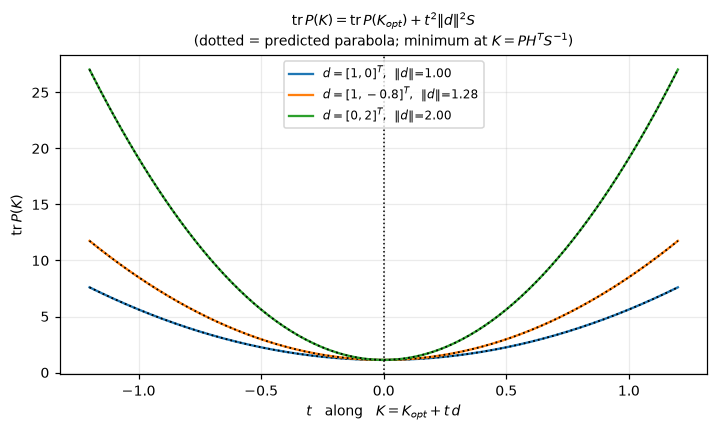

dtr/dK at K_opt = [0. 0.]  (zero)
curvature depends only on ||d||, not its direction -- because the quadratic
term of the Joseph form is (K-K_opt) S (K-K_opt)^T with S a scalar here.


In [16]:
# trace(P(K)) is a parabola in every direction of gain space, minimised at K_opt.
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ts = np.linspace(-1.2, 1.2, 241)
for d in [np.array([[1.0], [0.0]]), np.array([[1.0], [-0.8]]), np.array([[0.0], [2.0]])]:
    tr = [np.trace(P_joseph(K_opt + t*d, P3, H3, R3)) for t in ts]
    ax.plot(ts, tr, label=rf"$d=[{d[0,0]:g},{d[1,0]:g}]^T$,  $\|d\|$={norm(d):.2f}")
    # predicted parabola: tr P(K_opt) + t^2 ||d||^2 S   -- curvature depends ONLY on ||d||
    ax.plot(ts, np.trace(P_joseph(K_opt, P3, H3, R3)) + ts**2 * norm(d)**2 * S3[0, 0],
            "k:", lw=1.2)
ax.axvline(0, color="k", ls=":", lw=1)
ax.set_xlabel(r"$t$   along   $K = K_{opt} + t\,d$")
ax.set_ylabel(r"$\mathrm{tr}\,P(K)$")
ax.set_title(r"$\mathrm{tr}\,P(K)=\mathrm{tr}\,P(K_{opt})+t^2\|d\|^2S$"
             "\n(dotted = predicted parabola; minimum at $K=PH^TS^{-1}$)", fontsize=9)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# the gradient really does vanish there
grad = -2*P3 @ H3.T + 2*K_opt @ S3
print("dtr/dK at K_opt =", grad.ravel(), " (zero)")
print("curvature depends only on ||d||, not its direction -- because the quadratic")
print("term of the Joseph form is (K-K_opt) S (K-K_opt)^T with S a scalar here.")

Because the objective is $\operatorname{tr}P(K)$ — a *sum of variances* — you might worry the
minimiser depends on your choice of coordinates. It does not: $K_{\text{opt}}$ minimises
$u^{\mathsf T}P(K)u$ *simultaneously for every direction $u$*, i.e. $P(K_{\text{opt}}) \preceq P(K)$ in the
Loewner order for all $K$. Complete the square in the Joseph form:

$$P(K) = \underbrace{P^- - P^-H^{\mathsf T}S^{-1}HP^-}_{P(K_{\text{opt}})} \;+\; (K-K_{\text{opt}})\,S\,(K-K_{\text{opt}})^{\mathsf T} ,$$

and the second term is PSD, vanishing only at $K=K_{\text{opt}}$. That is the whole optimality proof —
completing the square with matrices.

In [17]:
K_test = K_opt + np.array([[0.7], [0.25]])
lhs = P_joseph(K_test, P3, H3, R3)
rhs = P_joseph(K_opt, P3, H3, R3) + (K_test-K_opt) @ S3 @ (K_test-K_opt).T
print("completing the square holds exactly?", np.allclose(lhs, rhs))
print("P(K) - P(K_opt) eigenvalues (>= 0 => Loewner order):",
      eigh(lhs - P_joseph(K_opt, P3, H3, R3))[0])

completing the square holds exactly? True
P(K) - P(K_opt) eigenvalues (>= 0 => Loewner order): [0.    2.486]


---
## 5. Four faces of the same update

The measurement update can be written four ways. They are algebraically identical, but each one
makes a different fact obvious — and each corresponds to a different practical implementation.

### 5.1 Information form: **information adds**

Define the *information matrix* $Y = P^{-1}$ and *information vector* $\iota = P^{-1}\mu$. Then the
update is literally addition:

$$Y^+ = Y^- + H^{\mathsf T}R^{-1}H, \qquad \iota^+ = \iota^- + H^{\mathsf T}R^{-1}z .$$

No gain, no inverse of $S$, no subtraction. Reading it off:

* Each measurement contributes $H^{\mathsf T}R^{-1}H \succeq 0$ — **information accumulates monotonically**.
* $\operatorname{rank}(H^{\mathsf T}R^{-1}H) = \operatorname{rank}(H) = m$. A scalar sensor adds information
  along **one direction only**, no matter how good it is. Everything else must come from the dynamics.
  (§8 turns this into observability.)
* $N$ independent sensors fuse by *summing* their $H_i^{\mathsf T}R_i^{-1}H_i$ — order-independent, trivially parallel. This is why distributed estimation uses the information filter.
* The price: prediction becomes the ugly step, and you cannot start with "no information at all"
  in covariance form ($P_0=\infty$) — but you *can* in information form ($Y_0=0$).

Proving the two forms agree **is** the Sherman–Morrison–Woodbury identity:

$$\big(P^{-1}+H^{\mathsf T}R^{-1}H\big)^{-1} \;=\; P - PH^{\mathsf T}\big(HPH^{\mathsf T}+R\big)^{-1}HP .$$

Left side inverts an $n\times n$; right side inverts an $m\times m$. For a 15-state biomechanical
model with one scalar sensor, that is a $15\times15$ inverse versus a $1\times1$ division — which is
exactly why the gain form is the one everybody implements.

In [18]:
Y_prior = inv(P3)
Y_post  = Y_prior + H3.T @ inv(R3) @ H3
show(r"P^{-1}", Y_prior, r"H^TR^{-1}H", H3.T @ inv(R3) @ H3, r"(P^+)^{-1}", Y_post)

print("information form == gain form?      ", np.allclose(inv(Y_post), Ppos))
print("Woodbury identity holds?            ",
      np.allclose(inv(inv(P3) + H3.T @ inv(R3) @ H3),
                  P3 - P3 @ H3.T @ inv(H3 @ P3 @ H3.T + R3) @ H3 @ P3))
print("rank(H^T R^-1 H) = rank(H) =        ", matrix_rank(H3.T @ inv(R3) @ H3), matrix_rank(H3))
print("information added, eigenvalues:     ", eigh(H3.T @ inv(R3) @ H3)[0],
      " <- only ONE nonzero: a scalar sensor informs one direction")

# the mean, in information coordinates
z_ = np.array([1.5])
iota_post = Y_prior @ mu3 + (H3.T @ inv(R3) @ z_)
print("\nmean from information form:", solve(Y_post, iota_post))
print("mean from gain form       :", kf_update(mu3, P3, z_, H3, R3)[0])

<IPython.core.display.Math object>

information form == gain form?       True
Woodbury identity holds?             True
rank(H^T R^-1 H) = rank(H) =         1 1
information added, eigenvalues:      [0. 2.]  <- only ONE nonzero: a scalar sensor informs one direction

mean from information form: [1.333 0.4  ]
mean from gain form       : [1.333 0.4  ]


### 5.2 Least squares: the update *is* a normal equation

The posterior mean is the minimiser of a weighted sum of squared residuals:

$$\hat x = \arg\min_x\ \underbrace{(x-\mu)^{\mathsf T}P^{-1}(x-\mu)}_{\text{trust the prior}}
        \;+\;\underbrace{(z-Hx)^{\mathsf T}R^{-1}(z-Hx)}_{\text{trust the sensor}} .$$

Inverse covariances are **weights**. Now *whiten*: factor $P = L_PL_P^{\mathsf T}$, $R = L_RL_R^{\mathsf T}$
(Cholesky), and note $\|r\|^2_{\Sigma^{-1}} = \|L^{-1}r\|_2^2$. Both terms become plain 2-norms, and
stacking them turns the whole update into one ordinary least-squares problem:

$$\hat x=\arg\min_x\left\|
\underbrace{\begin{bmatrix}L_P^{-1}\\ L_R^{-1}H\end{bmatrix}}_{A\ \in\ \mathbb R^{(n+m)\times n}}x-
\underbrace{\begin{bmatrix}L_P^{-1}\mu\\ L_R^{-1}z\end{bmatrix}}_{b}\right\|_2^2
\qquad\Longrightarrow\qquad
A^{\mathsf T}A\,\hat x = A^{\mathsf T}b .$$

And $A^{\mathsf T}A = P^{-1}+H^{\mathsf T}R^{-1}H = (P^+)^{-1}$ — the normal-equations matrix **is** the
posterior information matrix. So: **the Kalman filter is recursive weighted least squares**, and the
Gram matrix of the whitened system is the thing you invert to get the covariance.

In [19]:
z_  = np.array([1.5])
LP  = cholesky(P3); LR = cholesky(R3)
LPi = solve(LP, np.eye(2)); LRi = solve(LR, np.eye(1))

A = np.vstack([LPi,       LRi @ H3])                    # (3, 2)
b = np.concatenate([LPi @ mu3, (LRi @ z_)])             # (3,)

x_ls, *_ = lstsq(A, b, rcond=None)
x_kf, P_kf, _ = kf_update(mu3, P3, z_, H3, R3)

print("least-squares solution :", x_ls)
print("Kalman  mean           :", x_kf, "   equal?", np.allclose(x_ls, x_kf))
print("(A^T A)^-1 == P^+ ?    ", np.allclose(inv(A.T @ A), P_kf))
show("A", A, "A^TA", A.T @ A, r"(A^TA)^{-1}", inv(A.T @ A))

# whitening really does turn a Mahalanobis norm into a 2-norm
r = np.array([0.7, -1.3])
print("\nr^T P^-1 r      =", r @ inv(P3) @ r)
print("|| L_P^-1 r ||^2 =", norm(LPi @ r)**2)

least-squares solution : [1.333 0.4  ]
Kalman  mean           : [1.333 0.4  ]    equal? True
(A^T A)^-1 == P^+ ?     True


<IPython.core.display.Math object>


r^T P^-1 r      = 3.68515625
|| L_P^-1 r ||^2 = 3.6851562499999995


### 5.3 Orthogonal projection: the innovation is what is left over

Put a geometry on random vectors: $\langle a,b\rangle = \mathbb E[ab^{\mathsf T}]$. Then
"uncorrelated" means "orthogonal", and the update is a projection.

The optimal estimate is the projection of $x$ onto the subspace spanned by the measurements, and the
**orthogonality principle** says the leftover error is orthogonal to everything you used:

$$\mathbb E\big[(x-\hat x)\,y^{\mathsf T}\big] = 0,\qquad y = z-H\hat x^- .$$

Check it directly: $\mathbb E[(x-\hat x)y^{\mathsf T}] = \mathbb E[(x-\hat x^- - Ky)y^{\mathsf T}]
= PH^{\mathsf T} - KS$, which vanishes exactly when $K = PH^{\mathsf T}S^{-1}$. **Same equation as §3.**
Decorrelating, projecting, and minimising the trace are one condition wearing three hats.

Run forward in time this becomes Gram–Schmidt: the innovation sequence $\{y_k\}$ is the
orthogonalisation of the measurement sequence $\{z_k\}$. Hence the standard diagnostic —
**a correctly tuned filter has white innovations** (§7). Any leftover correlation is information
you failed to extract.

In [20]:
N  = 300_000
Xs = rng.multivariate_normal(mu3, P3, N).T
Zs = H3 @ Xs + np.sqrt(R3[0, 0]) * rng.standard_normal((1, N))

Yi   = Zs - H3 @ mu3[:, None]                  # innovations
Xhat = mu3[:, None] + K_opt @ Yi               # posterior means
err  = Xs - Xhat

print("E[err @ y^T] with optimal K :", (err @ Yi.T / N).ravel(), "  <-- ~0, orthogonal")
err_bad = Xs - (mu3[:, None] + K_bad @ Yi)
print("E[err @ y^T] with wrong   K :", (err_bad @ Yi.T / N).ravel(),
      "  <-- not orthogonal: information left on the table")
print("\nalgebraically  P H^T - K S =", (P3 @ H3.T - K_opt @ S3).ravel())

E[err @ y^T] with optimal K : [0.001 0.002]   <-- ~0, orthogonal
E[err @ y^T] with wrong   K : [-1.801  1.353]   <-- not orthogonal: information left on the table

algebraically  P H^T - K S = [0. 0.]


### 5.4 Square root: propagate $L$, never $P$

$P$ is always used as a quadratic form, so you can carry its factor $L$ (with $LL^{\mathsf T}=P$)
instead. Two reasons this matters:

* **Conditioning.** $\operatorname{cond}(P)=\operatorname{cond}(L)^2$. Working with $L$ halves the
  condition number, i.e. buys back the digits that squaring destroyed.
* **Structural positivity.** $LL^{\mathsf T}\succeq0$ by construction, so $P$ *cannot* go indefinite,
  no matter how many updates you run. Long biomechanical trials with stiff, nearly-singular $P$
  are exactly where the naive form falls over.

Both steps become **QR factorisations**, using the fact that $A$ in $P=AA^{\mathsf T}$ is only defined up
to an orthogonal factor — QR just picks a triangular representative.

*Predict.* Stack $\;M=\begin{bmatrix}(FL)^{\mathsf T}\\ L_Q^{\mathsf T}\end{bmatrix}$, so
$M^{\mathsf T}M = FPF^{\mathsf T}+Q$. If $M = QU$ with $U$ upper triangular, then $U^{\mathsf T}U = M^{\mathsf T}M$,
so $L^- = U^{\mathsf T}$. **The predict step is one QR.**

*Update.* Stack the pre-array
$\;\mathcal A=\begin{bmatrix}L_R^{\mathsf T} & 0\\ (HL)^{\mathsf T} & L^{\mathsf T}\end{bmatrix}$,
whose Gram matrix $\mathcal A^{\mathsf T}\mathcal A=\begin{bmatrix}S & HP\\ PH^{\mathsf T}&P\end{bmatrix}$ is the
joint covariance from §3. QR it, $\mathcal A = QU$, and read the blocks straight off $U$:

$$U=\begin{bmatrix}L_S^{\mathsf T} & (KL_S)^{\mathsf T}\\ 0 & (L^+)^{\mathsf T}\end{bmatrix}
\;\Longrightarrow\; S = L_SL_S^{\mathsf T},\quad K=(KL_S)L_S^{-1},\quad P^+=L^+(L^+)^{\mathsf T}.$$

Triangularising the joint covariance's square root *is* the Schur complement — same factorisation as
§3's $LDL^{\mathsf T}$, done on the factor instead of the matrix. The gain and the posterior covariance
fall out of one orthogonal triangularisation, with **no matrix inverted** and no subtraction that
could ever produce a negative eigenvalue.

In [21]:
def _pos_diag(U):
    """QR's R factor has arbitrary sign; flip rows so the diagonal is positive."""
    d = np.sign(np.diag(U)); d[d == 0] = 1.0
    return np.diag(d) @ U

def sqrt_predict(L, F, LQ):
    """L L^T = P, LQ LQ^T = Q  ->  L_pred with L_pred L_pred^T = F P F^T + Q."""
    M = np.vstack([(F @ L).T, LQ.T])          # M^T M = F P F^T + Q
    _, U = qr(M)
    return _pos_diag(U).T

def sqrt_update(L, H, LR):
    """One QR gives S, K and the posterior factor -- no inverses of P, no subtraction."""
    n, m = L.shape[0], H.shape[0]
    A = np.block([[LR.T,        np.zeros((m, n))],
                  [(H @ L).T,   L.T            ]])
    _, U = qr(A); U = _pos_diag(U)
    LS   = U[:m, :m].T          # S     = LS LS^T
    KLS  = U[:m, m:].T          #       = K @ LS
    Lpos = U[m:, m:].T          # P^+   = Lpos Lpos^T
    return Lpos, KLS @ inv(LS), LS @ LS.T

# --- verify against the ordinary filter ------------------------------------
Fq, Qq = np.array([[1.0, 0.1], [0.0, 1.0]]), 0.05*np.eye(2)
L0     = cholesky(P3)

Lp = sqrt_predict(L0, Fq, cholesky(Qq))
print("sqrt predict == F P F^T + Q ?", np.allclose(Lp @ Lp.T, Fq @ P3 @ Fq.T + Qq))

Lu, Ksq, Ssq = sqrt_update(L0, H3, cholesky(R3))
print("sqrt update  P^+ matches ?   ", np.allclose(Lu @ Lu.T, Ppos))
print("sqrt update  K   matches ?   ", np.allclose(Ksq, K_opt))
print("sqrt update  S   matches ?   ", np.allclose(Ssq, S3))

P_ill = cov_from(1.0, 1e-4, 0.999)
print(f"\ncond(P) = {cond(P_ill):.3e}   cond(L) = {cond(cholesky(P_ill)):.3e}"
      f"   ratio = {cond(P_ill)/cond(cholesky(P_ill)):.3e}   (= cond(L), i.e. cond(P)=cond(L)^2)")

sqrt predict == F P F^T + Q ? True
sqrt update  P^+ matches ?    True
sqrt update  K   matches ?    True
sqrt update  S   matches ?    True

cond(P) = 5.003e+10   cond(L) = 2.237e+05   ratio = 2.237e+05   (= cond(L), i.e. cond(P)=cond(L)^2)


### The three forms, raced to destruction

The recipe for breaking $(I-KH)P$: a **strongly correlated prior** (so $P$ is nearly singular), a
**very sharp sensor** ($R\to0$, so $I-KH$ is nearly a projection with a tiny surviving part), and
**no process noise** to regularise it. Then run in `float32`. This is not a contrived corner —
it is what a stiff, highly-coupled biomechanical model with a good sensor looks like.

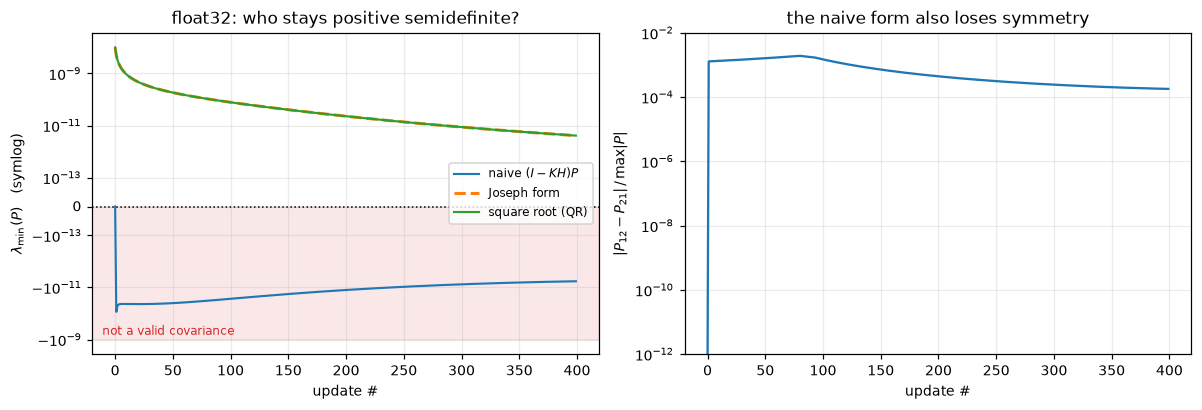

naive $(I-KH)P$        lambda_min < 0 on 399/400 updates    range [-8.63e-11, +0.00e+00]
Joseph form            lambda_min < 0 on   0/400 updates    range [+4.10e-12, +1.00e-08]
square root (QR)       lambda_min < 0 on   0/400 updates    range [+4.10e-12, +1.00e-08]

max relative asymmetry of the naive P: 1.92e-03


In [22]:
def race(steps=400, dtype=np.float32):
    dt_  = dtype(1e-2)
    F    = np.array([[1, dt_], [0, 1]], dtype=dtype)
    H    = np.array([[1.0, 0.0]], dtype=dtype)
    I2   = np.eye(2, dtype=dtype)
    R    = np.array([[1e-8]], dtype=dtype)            # very sharp sensor
    Q    = np.zeros((2, 2), dtype=dtype)              # no regularising process noise
    LQ   = np.zeros((2, 2), dtype=dtype)
    P0   = np.array([[1e6, 0.9999e6], [0.9999e6, 1e6]])   # nearly singular prior

    P_n, P_j = P0.astype(dtype), P0.astype(dtype)
    L        = cholesky(P0).astype(dtype)
    LR       = cholesky(R.astype(float)).astype(dtype)

    out = []
    for _ in range(steps):
        P_n = F @ P_n @ F.T + Q
        P_j = F @ P_j @ F.T + Q
        L   = sqrt_predict(L, F, LQ).astype(dtype)

        S = H @ P_n @ H.T + R
        K = P_n @ H.T @ inv(S)
        P_n = (I2 - K @ H) @ P_n                      # naive -- note: no sym() rescue

        S = H @ P_j @ H.T + R
        K = P_j @ H.T @ inv(S)
        P_j = P_joseph(K, P_j, H, R)                  # Joseph

        L = sqrt_update(L, H, LR)[0].astype(dtype)    # square root

        Lf = L.astype(float)
        out.append([eigh(sym(P_n.astype(float)))[0].min(),
                    eigh(sym(P_j.astype(float)))[0].min(),
                    eigh(Lf @ Lf.T)[0].min(),
                    abs(float(P_n[0, 1] - P_n[1, 0])) / float(abs(P_n).max())])
    return np.array(out)

hist  = race()
names = [r"naive $(I-KH)P$", "Joseph form", "square root (QR)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for j, (lab, st) in enumerate(zip(names, ["-", "--", "-"])):
    axes[0].plot(hist[:, j], st, label=lab, lw=2.0 if j == 1 else 1.4)
# Joseph is dashed because it and the square-root form agree to plotting precision.
# symlog: the interesting values straddle zero across many decades
axes[0].set_yscale("symlog", linthresh=1e-13)
axes[0].axhline(0, color="k", lw=1, ls=":")
axes[0].axhspan(-1e-9, 0, color="C3", alpha=.10)
axes[0].text(0.02, 0.06, "not a valid covariance", transform=axes[0].transAxes,
             color="C3", fontsize=8)
axes[0].set_xlabel("update #"); axes[0].set_ylabel(r"$\lambda_{\min}(P)$   (symlog)")
axes[0].set_title("float32: who stays positive semidefinite?")
axes[0].legend(fontsize=8, loc="center right")

axes[1].semilogy(np.maximum(hist[:, 3], 1e-12), color="C0")
axes[1].set_ylim(1e-12, 1e-2)
axes[1].set_xlabel("update #"); axes[1].set_ylabel(r"$|P_{12}-P_{21}|\,/\,\max|P|$")
axes[1].set_title(r"the naive form also loses symmetry")
plt.tight_layout(); plt.show()

neg = (hist[:, :3] < 0).sum(axis=0)
for lab, n_, col in zip(names, neg, hist[:, :3].T):
    print(f"{lab:22s} lambda_min < 0 on {n_:3d}/400 updates    "
          f"range [{col.min():+.2e}, {col.max():+.2e}]")
print(f"\nmax relative asymmetry of the naive P: {hist[:, 3].max():.2e}")

The naive form spends essentially the whole run with a **negative eigenvalue** — a covariance matrix
claiming negative variance in some direction. Downstream that means `cholesky` throws, gains come out
with the wrong sign, and the filter diverges. Joseph and the square-root form never go negative,
and for a structural reason, not a lucky one:

* Joseph is $XPX^{\mathsf T} + KRK^{\mathsf T}$ — a **sum of two congruences**, so it is symmetric and PSD by construction (§2), whatever rounding does to $X$ and $K$.
* The square-root form never forms $P$ at all; it carries $L$, and $LL^{\mathsf T}\succeq0$ is not something arithmetic can violate.
* The naive $(I-KH)P$ is a product of two *different* matrices — not symmetric even in principle — and it reaches the answer by cancellation, which is exactly where float32 loses its digits.

This also connects back to §4: the Joseph form is exact **for any $K$**, and in floating point your
computed $K$ is always slightly off the optimum. Joseph absorbs that error; the naive form assumes it
away. In a well-conditioned problem the naive form is usually fine — but "usually fine" degrades with
state dimension, condition number, and sensor sharpness, and it fails silently.

---
## 6. The geometry of one update (interactive)

Now make §3 visible. State $x=(x_1,x_2)$ — think **joint angle** and **angular velocity**.
A single scalar sensor measures the combination $H = [\cos\theta,\ \sin\theta]$, so:

* $\theta = 0^\circ$: you measure the angle only,
* $\theta = 90^\circ$: you measure the angular velocity only,
* in between: a mixed sensor.

The set of states consistent with the reading is the **line** $\{x : Hx = z\}$, perpendicular to
$H^{\mathsf T}$, and $R$ gives it thickness.

Three things to hunt for:

1. **The mean moves along $PH^{\mathsf T}$, not along $H^{\mathsf T}$.** Both arrows are drawn. They only
   coincide when the prior is uncorrelated *and* isotropic. The prior's shape *steers* the correction.
2. **The posterior ellipse is squeezed in exactly one direction** — a rank-1 downdate
   $P^+ = P - \tfrac{(PH^{\mathsf T})(PH^{\mathsf T})^{\mathsf T}}{S}$. Perpendicular to the squeeze, the ellipse is untouched.
3. **Set $\rho = 0$ with $\theta=0^\circ$**: $K_2 = P_{21}/S = 0$, and the velocity estimate does not move at all. Now raise $\rho$: measuring the *angle* starts correcting the *velocity*. That is the entire magic of a Kalman filter, and it is one off-diagonal entry of $P$.

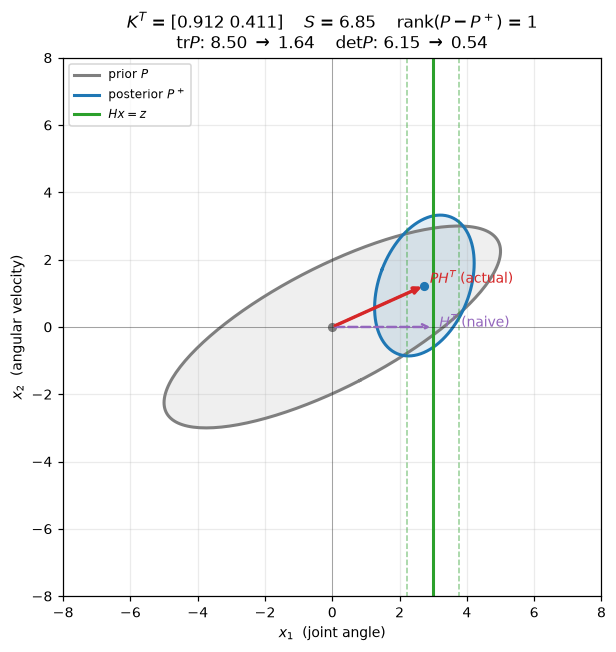

In [23]:
@interact(rho      =FloatSlider(value=0.75, min=-0.95, max=0.95, step=0.05),
          R_var    =FloatSlider(value=0.60, min=0.02,  max=6.0,  step=0.02),
          z        =FloatSlider(value=3.00, min=-6.0,  max=6.0,  step=0.1),
          theta_deg=FloatSlider(value=0.0,  min=0.0,   max=180., step=5.0))
def _update_geometry(rho, R_var, z, theta_deg):
    P = cov_from(2.5, 1.5, rho)
    th = np.deg2rad(theta_deg)
    h  = np.array([np.cos(th), np.sin(th)])       # unit vector
    H  = h[None, :]                               # (1,2)
    R  = np.array([[R_var]])
    mu = np.zeros(2)

    xp, Pp, aux = kf_update(mu, P, np.array([z]), H, R)
    K, S = aux["K"], aux["S"][0, 0]

    fig, ax = plt.subplots(figsize=(6.0, 6.0))
    plot_ellipse(ax, mu, P,  color="C7", label="prior $P$",     fill=True)
    plot_ellipse(ax, xp, Pp, color="C0", label="posterior $P^+$", fill=True)

    # the measurement subspace {x : h.x = z}, thickened by +-1 sigma of R
    perp = np.array([-h[1], h[0]])
    s    = np.linspace(-9, 9, 2)
    for off, st, al in [(0, "-", 1.0), (np.sqrt(R_var), "--", .5), (-np.sqrt(R_var), "--", .5)]:
        pl = (z + off)*h[:, None] + perp[:, None]*s
        ax.plot(pl[0], pl[1], st, color="C2", lw=2 if off == 0 else 1, alpha=al,
                label=("$Hx=z$" if off == 0 else None))

    ax.annotate("", xy=xp, xytext=mu,
                arrowprops=dict(arrowstyle="-|>", color="C3", lw=2.2))
    for vec, c, lab in [(h*3.0, "C4", r"$H^T$ (naive)"),
                        ((P @ h)/norm(P @ h)*3.0, "C3", r"$PH^T$ (actual)")]:
        ax.annotate("", xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color=c, lw=1.6, ls="--"))
        ax.annotate(lab, vec*1.06, color=c, fontsize=9)

    axes_equal(ax, (-8, 8)); ax.legend(loc="upper left", fontsize=8)
    ax.set_xlabel("$x_1$  (joint angle)"); ax.set_ylabel("$x_2$  (angular velocity)")
    ax.set_title(f"$K^T$ = {np.round(K.ravel(),3)}    $S$ = {S:.2f}    "
                 f"rank$(P-P^+)$ = {matrix_rank(P - Pp)}\n"
                 f"tr$P$: {np.trace(P):.2f} $\\to$ {np.trace(Pp):.2f}    "
                 f"det$P$: {det(P):.2f} $\\to$ {det(Pp):.2f}")
    plt.tight_layout(); plt.show()

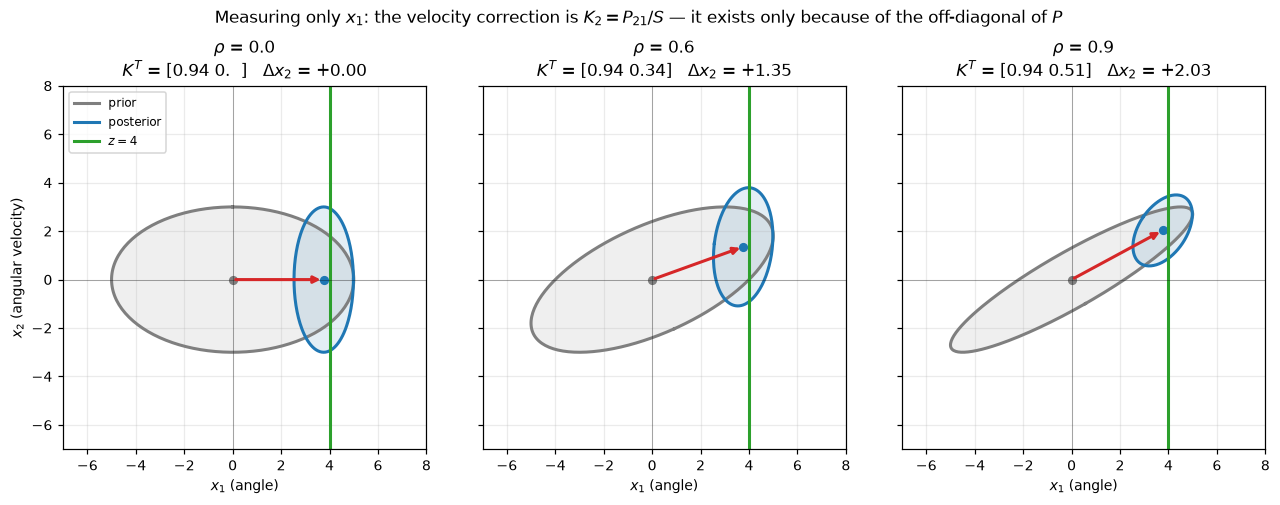

In [24]:
# The punchline, side by side: does measuring x1 move x2?
H6, R6 = np.array([[1.0, 0.0]]), np.array([[0.4]])
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharex=True, sharey=True)
for ax, rho in zip(axes, [0.0, 0.6, 0.9]):
    P = cov_from(2.5, 1.5, rho)
    xp, Pp, aux = kf_update(np.zeros(2), P, np.array([4.0]), H6, R6)
    plot_ellipse(ax, [0, 0], P,  color="C7", label="prior", fill=True)
    plot_ellipse(ax, xp,     Pp, color="C0", label="posterior", fill=True)
    ax.axvline(4.0, color="C2", lw=2, label="$z=4$")
    ax.annotate("", xy=xp, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color="C3", lw=2))
    ax.set_title(f"$\\rho$ = {rho}\n$K^T$ = {np.round(aux['K'].ravel(), 2)}"
                 f"   $\\Delta x_2$ = {xp[1]:+.2f}")
    axes_equal(ax, (-7, 8)); ax.set_xlabel("$x_1$ (angle)")
axes[0].set_ylabel("$x_2$ (angular velocity)"); axes[0].legend(fontsize=8)
plt.suptitle(r"Measuring only $x_1$: the velocity correction is $K_2=P_{21}/S$ "
             r"— it exists only because of the off-diagonal of $P$", y=1.02)
plt.tight_layout(); plt.show()

And the rank-1 statement, explicitly. For a scalar measurement ($m=1$, $S$ a number):

$$P^+ = P - \frac{(PH^{\mathsf T})(PH^{\mathsf T})^{\mathsf T}}{S}$$

which is a **rank-one downdate** — subtract an outer product of a single vector with itself. So a
scalar sensor can only ever shrink the ellipse along the single direction $PH^{\mathsf T}$; the
$(n-1)$-dimensional subspace orthogonal to it (in the $P^{-1}$ metric) is left exactly as it was.

In [25]:
P6  = cov_from(2.5, 1.5, 0.75)
c   = P6 @ H6.T                     # P H^T,  (2,1)
S6  = (H6 @ P6 @ H6.T + R6)[0, 0]
P6p = P6 - (c @ c.T) / S6
print("rank-1 downdate == kf_update ?", np.allclose(P6p, kf_update(np.zeros(2), P6, np.array([0.]), H6, R6)[1]))
print("rank(P - P^+) =", matrix_rank(P6 - P6p), "  (one scalar sensor -> one direction)")

# a direction P^-1-orthogonal to the squeeze is untouched
u = np.array([-c[1, 0], c[0, 0]])                       # orthogonal to P H^T
u = u / norm(u)
print(f"\nvariance along the squeeze direction PH^T : "
      f"{(c.ravel() @ P6 @ c.ravel())/norm(c)**2:.4f} -> "
      f"{(c.ravel() @ P6p @ c.ravel())/norm(c)**2:.4f}")
print(f"variance along the orthogonal direction   : "
      f"{u @ P6 @ u:.4f} -> {u @ P6p @ u:.4f}")

rank-1 downdate == kf_update ? True
rank(P - P^+) = 1   (one scalar sensor -> one direction)

variance along the squeeze direction PH^T : 7.6814 -> 0.6178
variance along the orthogonal direction   : 0.8186 -> 0.8186


---
## 7. A full run: knee flexion angle from a noisy sensor

A concrete, biomechanics-flavoured model: a slow passive knee flexion–extension (think a clinician
moving the joint through its range) recorded by a 100 Hz electrogoniometer. State
$x = \begin{bmatrix}\theta\\ \omega\end{bmatrix}$ = (flexion angle in degrees, angular velocity in deg/s).
The dynamics are "constant velocity, disturbed by unknown angular acceleration":

$$F=\begin{bmatrix}1&\Delta t\\0&1\end{bmatrix},\qquad
Q=q\begin{bmatrix}\Delta t^3/3 & \Delta t^2/2\\ \Delta t^2/2 & \Delta t\end{bmatrix},\qquad
H=\begin{bmatrix}1&0\end{bmatrix} .$$

That $Q$ is not arbitrary. Model the disturbance as a white noise *acceleration* of spectral density
$q$ entering through $G=[\Delta t^2/2,\ \Delta t]^{\mathsf T}$; then
$Q=\int_0^{\Delta t} F(\tau)\,\mathrm{diag}(0,q)\,F(\tau)^{\mathsf T}\,\mathrm d\tau$, and the result is the
matrix above. **It is a congruence, integrated** — §2 again. Note $Q$ has full rank but is
badly conditioned: a single acceleration channel drives both states, so $Q$ is nearly rank-1 for
small $\Delta t$, which is exactly why its off-diagonal matters.

We never measure $\omega$. The filter has to *infer* it — through the off-diagonal of $P$ that the
shear in $F$ creates. §6 is about to pay off.

We generate the ground truth **from this same model**, by driving it with white acceleration noise of
known strength $q_{\text{true}}$. That is deliberate: with a correctly specified model, the filter's
covariance is a claim we can actually check, and the diagnostics below have a right answer to hit.
(Real data is never generated by your model — the last cell of this section shows what a *wrong* $q$
looks like, which is what mis-specification feels like in practice.)

In [26]:
dt   = 1/100.0
T    = 3.0
Nk   = int(T/dt)
tt   = np.arange(Nk)*dt

F7 = np.array([[1.0, dt], [0.0, 1.0]])
H7 = np.array([[1.0, 0.0]])

def Q_cwna(q, dt=dt):
    """Continuous white-noise-acceleration process noise: integrate the congruence."""
    return q * np.array([[dt**3/3, dt**2/2],
                         [dt**2/2, dt      ]])

q_true  = 1.5e3                               # (deg/s^2)^2/Hz -- true disturbance strength
Q7      = Q_cwna(q_true)
sigma_z = 2.5                                 # goniometer noise, degrees
R7      = np.array([[sigma_z**2]])

# ---- ground truth, simulated from the model itself ------------------------
sim  = np.random.default_rng(1)
LQ   = cholesky(Q7)
x_   = np.array([15.0, 80.0])                 # 15 deg flexion, extending at 80 deg/s
X_true = np.empty((2, Nk))
for k in range(Nk):
    x_ = F7 @ x_ + LQ @ sim.standard_normal(2)
    X_true[:, k] = x_
theta_true, omega_true = X_true
Z = theta_true + sigma_z*sim.standard_normal(Nk)

show("F", F7, "Q", Q7, "H", H7, "R", R7)
print("Q eigenvalues:", eigh(Q7)[0], "  cond(Q) = %.3e  <-- nearly rank 1" % cond(Q7))
print(f"true angle spans [{theta_true.min():.0f}, {theta_true.max():.0f}] deg,"
      f"  angular velocity [{omega_true.min():.0f}, {omega_true.max():.0f}] deg/s")

<IPython.core.display.Math object>

Q eigenvalues: [ 0. 15.]   cond(Q) = 1.200e+05  <-- nearly rank 1
true angle spans [16, 87] deg,  angular velocity [-40, 88] deg/s


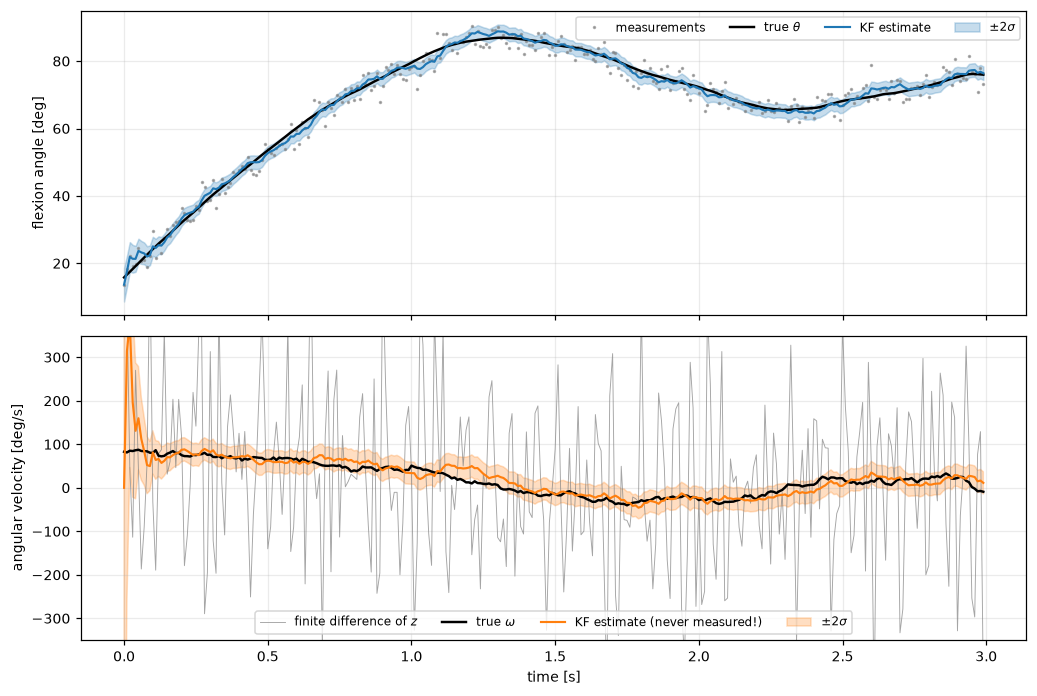

angle    RMSE   raw sensor   2.66 deg    Kalman   1.16 deg   (2.3x better)
velocity RMSE   finite diff 185.8 deg/s  Kalman  27.1 deg/s   (6.9x better)      [true |omega| std = 37 deg/s]

The velocity is the real prize: it is never measured, and differentiating the raw
signal amplifies the sensor noise by 1/dt = 100. The filter gets it from P's off-diagonal.


In [27]:
def run_kf(Z, x0, P0, F, Q, H, R):
    """Manual Kalman filter. Returns everything you need for diagnostics."""
    n  = len(x0)
    out = dict(x=[], P=[], Ppred=[], K=[], y=[], S=[])
    x, P = np.array(x0, float), np.array(P0, float)
    for z in Z:
        x, P = kf_predict(x, P, F, Q)
        out["Ppred"].append(P.copy())
        x, P, aux = kf_update(x, P, np.atleast_1d(z), H, R)
        out["x"].append(x.copy());   out["P"].append(P.copy())
        out["K"].append(aux["K"].copy())
        out["y"].append(aux["y"].copy()); out["S"].append(aux["S"].copy())
    return {k: np.array(v) for k, v in out.items()}

res = run_kf(Z, [Z[0], 0.0], np.diag([50.0**2, 500.0**2]), F7, Q7, H7, R7)

Xh  = res["x"].T                                  # 2 x N
sd  = np.sqrt(np.array([np.diag(P) for P in res["P"]])).T

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True)
axes[0].plot(tt, Z, ".", ms=2.5, color="C7", alpha=.6, label="measurements")
axes[0].plot(tt, theta_true, "k", lw=1.6, label="true $\\theta$")
axes[0].plot(tt, Xh[0], "C0", lw=1.4, label="KF estimate")
axes[0].fill_between(tt, Xh[0]-2*sd[0], Xh[0]+2*sd[0], color="C0", alpha=.25, label="$\\pm2\\sigma$")
axes[0].set_ylabel("flexion angle [deg]"); axes[0].legend(ncol=4, fontsize=8)

omega_fd = np.gradient(Z, dt)          # the obvious alternative: differentiate the raw signal
axes[1].plot(tt, omega_fd, color="C7", lw=.6, alpha=.7, label="finite difference of $z$")
axes[1].plot(tt, omega_true, "k", lw=1.6, label="true $\\omega$")
axes[1].plot(tt, Xh[1], "C1", lw=1.4, label="KF estimate (never measured!)")
axes[1].fill_between(tt, Xh[1]-2*sd[1], Xh[1]+2*sd[1], color="C1", alpha=.25, label="$\\pm2\\sigma$")
axes[1].set_ylabel("angular velocity [deg/s]"); axes[1].set_xlabel("time [s]")
axes[1].set_ylim(-350, 350); axes[1].legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

rmse_raw = np.sqrt(np.mean((Z - theta_true)**2))
rmse_kf  = np.sqrt(np.mean((Xh[0] - theta_true)**2))
rmse_fd  = np.sqrt(np.mean((omega_fd - omega_true)**2))
rmse_kfv = np.sqrt(np.mean((Xh[1] - omega_true)**2))
print(f"angle    RMSE   raw sensor {rmse_raw:6.2f} deg    Kalman {rmse_kf:6.2f} deg"
      f"   ({rmse_raw/rmse_kf:.1f}x better)")
print(f"velocity RMSE   finite diff {rmse_fd:5.1f} deg/s  Kalman {rmse_kfv:5.1f} deg/s"
      f"   ({rmse_fd/rmse_kfv:.1f}x better)      [true |omega| std = {omega_true.std():.0f} deg/s]")
print("\nThe velocity is the real prize: it is never measured, and differentiating the raw")
print("signal amplifies the sensor noise by 1/dt = 100. The filter gets it from P's off-diagonal.")

### Is the filter telling the truth about its own uncertainty?

A covariance is a *claim*. Two standard checks, both pure linear algebra on the innovations:

**NIS** (normalised innovation squared): $\;\epsilon_k = y_k^{\mathsf T}S_k^{-1}y_k$. If the filter is
consistent, $\epsilon_k \sim \chi^2_m$, so about 95% of samples should sit inside the $\chi^2_m$
interval and the mean should be $\approx m$. This is just the Mahalanobis norm of §1 applied in
measurement space.

**Whiteness**: by §5.3 the innovations are the Gram–Schmidt residuals of the measurement sequence, so
they must be uncorrelated across time. Structure in the autocorrelation = information the filter is
not using (usually: $Q$ too small, so the model is trusted more than it deserves).

Both tests are run below for the correctly tuned filter **and** for one given a $q$ that is 100×
too small — so you can see what failure actually looks like.

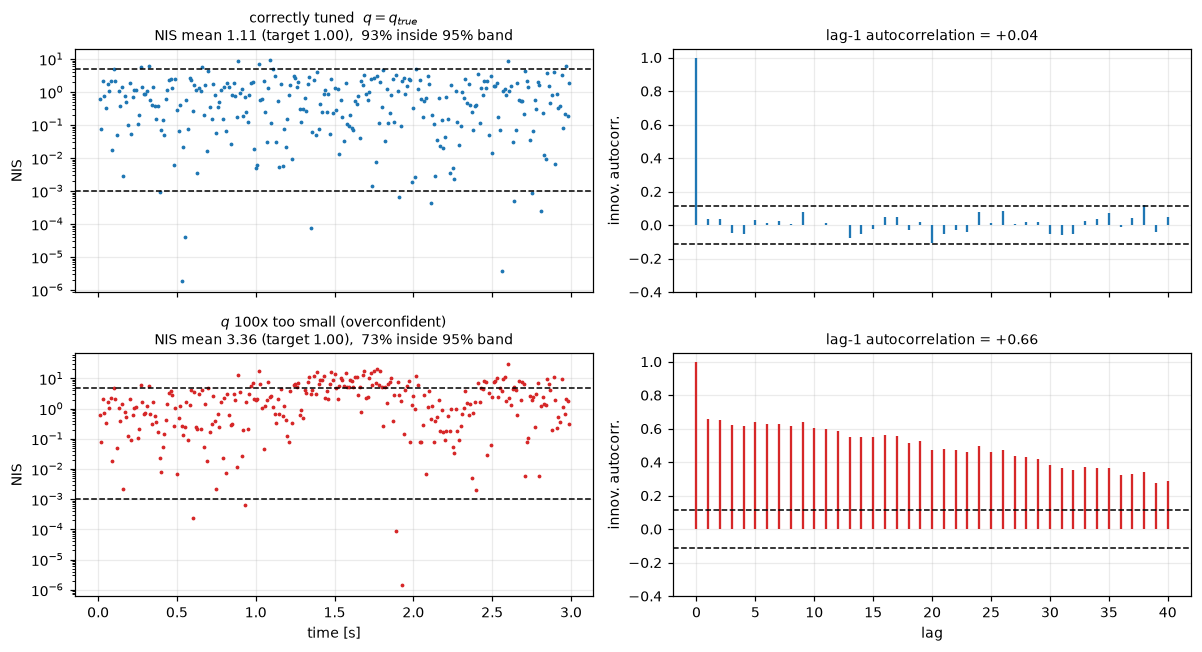

In [28]:
from scipy.stats import chi2
lo, hi = chi2.ppf([0.025, 0.975], df=1)

def diagnostics(r):
    nis = np.array([y @ inv(S) @ y for y, S in zip(r["y"], r["S"])])
    nu  = r["y"].ravel() / np.sqrt(r["S"][:, 0, 0])
    nu  = nu - nu.mean()
    ac  = np.correlate(nu, nu, "full")[len(nu)-1:]
    return nis, ac/ac[0]

runs = [("correctly tuned  $q=q_{true}$", res, "C0"),
        ("$q$ 100x too small (overconfident)",
         run_kf(Z, [Z[0], 0.0], np.diag([50.0**2, 500.0**2]),
                F7, Q_cwna(q_true/100), H7, R7), "C3")]

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex="col")
for row, (lab, r, c) in enumerate(runs):
    nis, ac = diagnostics(r)
    axes[row, 0].plot(tt, nis, ".", ms=3, color=c)
    axes[row, 0].axhline(hi, color="k", ls="--", lw=1)
    axes[row, 0].axhline(lo, color="k", ls="--", lw=1)
    axes[row, 0].set_yscale("log"); axes[row, 0].set_ylabel("NIS")
    axes[row, 0].set_title(f"{lab}\nNIS mean {nis.mean():.2f} (target 1.00),  "
                           f"{100*np.mean((nis>lo)&(nis<hi)):.0f}% inside 95% band", fontsize=9)
    axes[row, 1].stem(np.arange(41), ac[:41], linefmt=c, markerfmt=" ", basefmt=" ")
    b = 1.96/np.sqrt(len(nis))
    axes[row, 1].axhline(b, color="k", ls="--", lw=1); axes[row, 1].axhline(-b, color="k", ls="--", lw=1)
    axes[row, 1].set_ylabel("innov. autocorr."); axes[row, 1].set_ylim(-.4, 1.05)
    axes[row, 1].set_title(f"lag-1 autocorrelation = {ac[1]:+.2f}", fontsize=9)
axes[1, 0].set_xlabel("time [s]"); axes[1, 1].set_xlabel("lag")
plt.tight_layout(); plt.show()

The bottom row is the signature of an overconfident filter: $P$ is too small, so the filter under-weights
each measurement, the innovations stay **correlated across time** (lag-1 $\approx 0.7$), and the NIS
sits well above 1 — the errors are much bigger than the covariance claims. Notice that this is
detectable **without ground truth**: you only need $y_k$ and $S_k$, both of which the filter already
computes. That is the practical value of §5.3's orthogonality principle.

### The covariance recursion is a Riccati equation

Substitute the update into the predict step and the covariance closes on itself, with **no reference
to any data**:

$$P^-_{k+1} = F\Big(P^-_k - P^-_kH^{\mathsf T}\big(HP^-_kH^{\mathsf T}+R\big)^{-1}HP^-_k\Big)F^{\mathsf T} + Q .$$

This is the **discrete-time Riccati recursion**. It is a deterministic matrix iteration, and for a
time-invariant, observable, controllable-from-noise system it converges to a unique PSD fixed point
$P^-_\infty$ — the solution of the **discrete algebraic Riccati equation (DARE)** — from *any*
positive-definite start. So a real filter becomes a constant-gain linear system after a short
transient, and you could precompute $K_\infty$ offline.

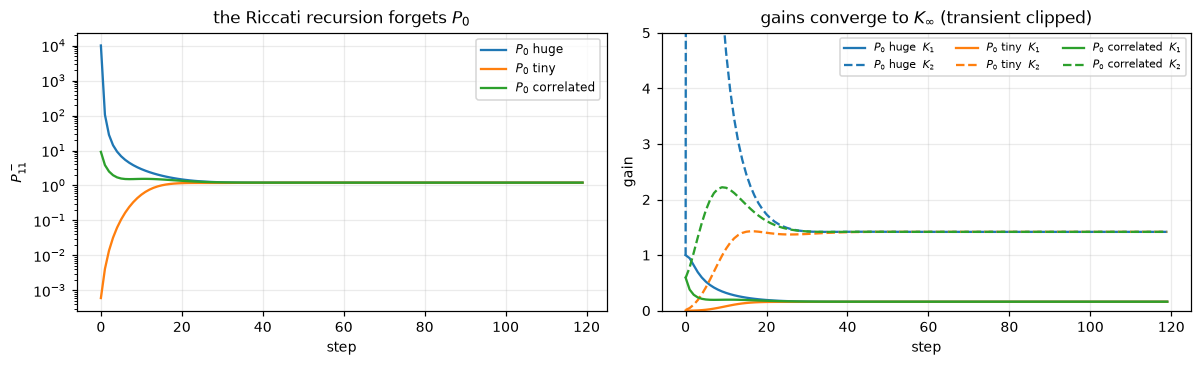

iterated P^-_inf:
 [[  1.203  10.573]
 [ 10.573 178.153]]
DARE solution   :
 [[  1.203  10.573]
 [ 10.573 178.153]]
agree? True


In [29]:
def riccati(F, H, Q, R, P0, steps):
    """Data-free covariance recursion. Returns histories of P^- and K."""
    P, Ps, Ks = np.array(P0, float), [], []
    for _ in range(steps):
        P = sym(F @ P @ F.T + Q)                       # predict
        S = H @ P @ H.T + R
        K = solve(S.T, (P @ H.T).T).T
        Ps.append(P.copy()); Ks.append(K.copy())
        P = sym((np.eye(len(P)) - K @ H) @ P)          # update
    return np.array(Ps), np.array(Ks)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for P0, lab, c in [(np.diag([1e4, 1e6]), "$P_0$ huge", "C0"),
                   (np.diag([1e-4, 1e-4]), "$P_0$ tiny", "C1"),
                   (np.array([[9., 5.], [5., 400.]]), "$P_0$ correlated", "C2")]:
    Ps, Ks = riccati(F7, H7, Q7, R7, P0, 120)
    axes[0].semilogy(Ps[:, 0, 0], c, label=lab)
    axes[1].plot(Ks[:, 0, 0], c, label=lab + "  $K_1$")
    axes[1].plot(Ks[:, 1, 0], c, ls="--", label=lab + "  $K_2$")
axes[0].set_xlabel("step"); axes[0].set_ylabel("$P^-_{11}$"); axes[0].legend(fontsize=8)
axes[0].set_title("the Riccati recursion forgets $P_0$")
axes[1].set_xlabel("step"); axes[1].set_ylabel("gain"); axes[1].legend(fontsize=7, ncol=3)
axes[1].set_ylim(0, 5)          # clip the first-step transient so both gains are visible
axes[1].set_title("gains converge to $K_\\infty$ (transient clipped)")
plt.tight_layout(); plt.show()

from scipy.linalg import solve_discrete_are
P_inf_dare = solve_discrete_are(F7.T, H7.T, Q7, R7)     # note the transposes
P_inf_iter = riccati(F7, H7, Q7, R7, np.diag([1e4, 1e6]), 3000)[0][-1]
print("iterated P^-_inf:\n", P_inf_iter)
print("DARE solution   :\n", P_inf_dare)
print("agree?", np.allclose(P_inf_iter, P_inf_dare, rtol=1e-6))

### Why the filter forgets a bad initial guess: $\rho\big((I-K_\infty H)F\big)<1$

Let $e_k = x_k - \hat x_k$. Chaining predict and update:

$$e_{k+1} = (I-K H)F\,e_k \;+\; \text{(noise terms)} .$$

The homogeneous part is governed by the **closed-loop matrix** $A_{cl} = (I-K_\infty H)F$. Its
spectral radius $\rho(A_{cl}) = \max_i|\lambda_i(A_{cl})|$ decides everything: any initial error decays
like $\rho(A_{cl})^k$. A well-posed filter always produces $\rho<1$ — this is the *guarantee* the
Riccati fixed point buys you, and it is the reason a filter started with a wildly wrong $\hat x_0$
still recovers.

<IPython.core.display.Math object>

eigenvalues of A_cl: [0.912+0.08j 0.912-0.08j]    spectral radius = 0.91575


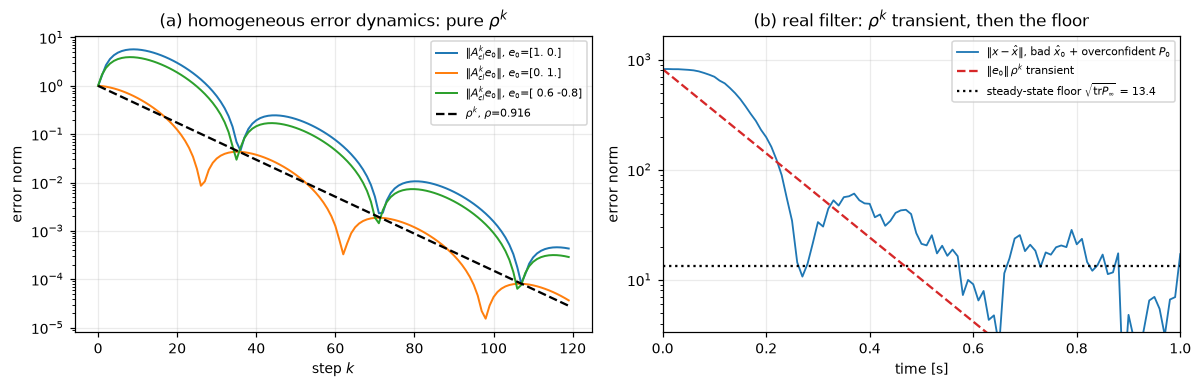

In [30]:
K_inf = solve((H7 @ P_inf_dare @ H7.T + R7).T, (P_inf_dare @ H7.T).T).T
A_cl  = (np.eye(2) - K_inf @ H7) @ F7
lam   = np.linalg.eigvals(A_cl)
rho_cl = np.abs(lam).max()
show(r"K_\infty", K_inf, "A_{cl}", A_cl)
print("eigenvalues of A_cl:", lam, "   spectral radius =", round(rho_cl, 5))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# (a) the pure homogeneous law: powers of A_cl, no noise anywhere.
ks = np.arange(120)
for i, e0 in enumerate([np.array([1.0, 0.0]), np.array([0.0, 1.0]), np.array([0.6, -0.8])]):
    axes[0].semilogy(ks, [norm(matrix_power(A_cl, k) @ e0) for k in ks],
                     f"C{i}", lw=1.3, label=rf"$\|A_{{cl}}^k e_0\|$, $e_0$={np.round(e0,1)}")
axes[0].semilogy(ks, rho_cl**ks, "k--", lw=1.5, label=rf"$\rho^k$, $\rho$={rho_cl:.3f}")
axes[0].set_xlabel("step $k$"); axes[0].set_ylabel("error norm")
axes[0].set_title("(a) homogeneous error dynamics: pure $\\rho^k$")
axes[0].legend(fontsize=7)

# (b) the real filter, started badly wrong: the same decay, until it hits the noise floor.
bad   = run_kf(Z, [-150.0, 900.0], np.diag([5.0**2, 5.0**2]), F7, Q7, H7, R7)
err   = norm(bad["x"].T - X_true, axis=0)
floor = np.sqrt(np.trace(P_inf_dare))
axes[1].semilogy(tt, err, "C0", lw=1.2, label=r"$\|x-\hat x\|$, bad $\hat x_0$ + overconfident $P_0$")
axes[1].semilogy(tt, err[0]*rho_cl**np.arange(Nk), "C3--", lw=1.5,
                 label=rf"$\|e_0\|\,\rho^k$ transient")
axes[1].axhline(floor, color="k", ls=":", lw=1.5,
                label=rf"steady-state floor $\sqrt{{\mathrm{{tr}}P_\infty}}$ = {floor:.1f}")
axes[1].set_xlabel("time [s]"); axes[1].set_ylabel("error norm")
axes[1].set_xlim(0, 1.0); axes[1].set_ylim(floor/4, 2*err.max())
axes[1].legend(fontsize=7); axes[1].set_title("(b) real filter: $\\rho^k$ transient, then the floor")
plt.tight_layout(); plt.show()

Panel (a) is the pure linear-algebra statement: $\|A_{cl}^k e_0\|$ decays like $\rho(A_{cl})^k$ for any
$e_0$ — the spectral radius controls the growth of matrix powers, full stop. Panel (b) is what you
actually see in a filter: the same $\rho^k$ transient, but it stops at the **steady-state error floor**
$\sqrt{\operatorname{tr}P_\infty}$, because new process and measurement noise keeps arriving. The
homogeneous part is forgotten; the driven part never is. A filter that appears "stuck" at a nonzero
error is not necessarily broken — compare against $\sqrt{\operatorname{tr}P_\infty}$ before concluding anything.

### Tuning is choosing a ratio of two matrices

$q$ and $R$ do not matter individually — only $q/R$ does. That ratio decides where $K_\infty$ sits
between "trust the model" and "trust the sensor". Slide it and watch the classic trade-off:
small $q$ gives a smooth but laggy estimate that misses the peaks; large $q$ tracks the peaks and
inherits the sensor noise.

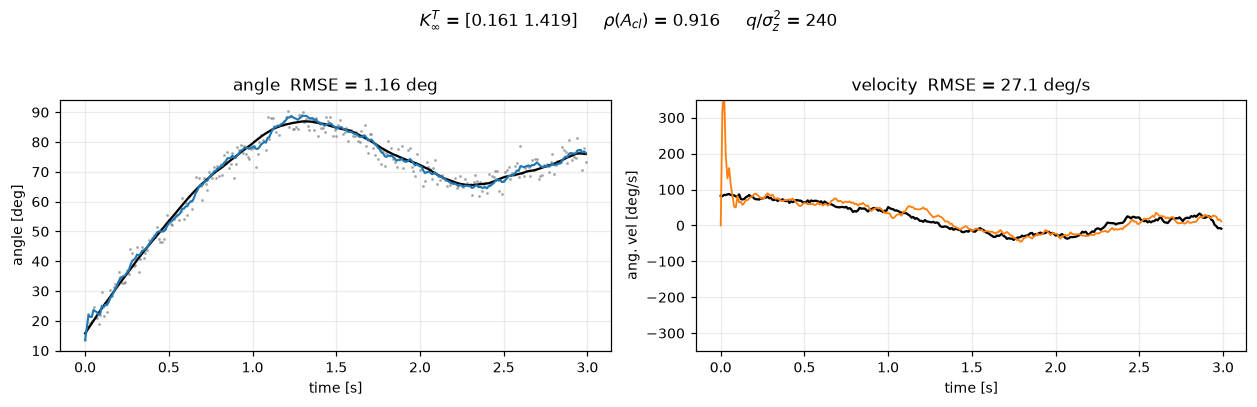

In [31]:
@interact(log10_q     =FloatSlider(value=np.log10(q_true), min=0.0, max=7.0, step=0.25),
          sigma_sensor=FloatSlider(value=2.5, min=0.5, max=8.0, step=0.25))
def _tuning(log10_q, sigma_sensor):
    qq = 10**log10_q
    Qv = Q_cwna(qq)
    Rv = np.array([[sigma_sensor**2]])
    r  = run_kf(Z, [Z[0], 0.0], np.diag([50.**2, 500.**2]), F7, Qv, H7, Rv)
    Xv = r["x"].T
    Pi = solve_discrete_are(F7.T, H7.T, Qv, Rv)
    Ki = solve((H7 @ Pi @ H7.T + Rv).T, (Pi @ H7.T).T).T
    Ac = (np.eye(2) - Ki @ H7) @ F7

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.5))
    axes[0].plot(tt, Z, ".", ms=2, color="C7", alpha=.5)
    axes[0].plot(tt, theta_true, "k", lw=1.5)
    axes[0].plot(tt, Xv[0], "C0", lw=1.4)
    axes[0].set_ylabel("angle [deg]"); axes[0].set_xlabel("time [s]")
    axes[0].set_title(f"angle  RMSE = {np.sqrt(np.mean((Xv[0]-theta_true)**2)):.2f} deg")
    axes[1].plot(tt, omega_true, "k", lw=1.5)
    axes[1].plot(tt, Xv[1], "C1", lw=1.2)
    axes[1].set_ylim(-350, 350); axes[1].set_ylabel("ang. vel [deg/s]"); axes[1].set_xlabel("time [s]")
    axes[1].set_title(f"velocity  RMSE = {np.sqrt(np.mean((Xv[1]-omega_true)**2)):.1f} deg/s")
    plt.suptitle(f"$K_\\infty^T$ = {np.round(Ki.ravel(), 3)}     "
                 f"$\\rho(A_{{cl}})$ = {np.abs(np.linalg.eigvals(Ac)).max():.3f}     "
                 f"$q/\\sigma_z^2$ = {qq/sigma_sensor**2:.3g}", y=1.04)
    plt.tight_layout(); plt.show()

---
## 8. Observability — the rank condition behind "why won't this state converge?"

§5.1 showed each measurement adds $H^{\mathsf T}R^{-1}H$, of rank $m$. With $n>m$ you are always short.
The dynamics make up the difference: over $k$ steps, information accumulates as roughly

$$\mathcal I_k \;\approx\; \sum_{j=0}^{k-1}(F^{j})^{\mathsf T}H^{\mathsf T}R^{-1}H F^{j}
\;=\; \mathcal O_k^{\mathsf T}\,(I\otimes R^{-1})\,\mathcal O_k,
\qquad
\mathcal O_k=\begin{bmatrix}H\\ HF\\ HF^2\\ \vdots\\ HF^{k-1}\end{bmatrix} .$$

$\mathcal O_n$ is the **observability matrix**, and $\mathcal I$ its Gramian. Cayley–Hamilton says
nothing new appears after $k=n$ rows-blocks, so the test is finite:

$$\operatorname{rank}\mathcal O_n = n \iff \text{every state direction is eventually informed.}$$

If $v\in\ker\mathcal O_n$, then $HF^jv = 0$ for all $j$: that combination of states leaves **no trace**
in any present or future measurement. The Gramian is singular along $v$, $v^{\mathsf T}\mathcal I v = 0$,
and the filter's variance in that direction **grows without bound**, no matter how much data you feed it.

This is a *rank* question, answered before you collect a single sample.

In [32]:
def observability(F, H):
    n = F.shape[0]
    return np.vstack([H @ matrix_power(F, k) for k in range(n)])

cases = {
    "A: constant velocity, measure angle": (F7, np.array([[1.0, 0.0]])),
    "B: two decoupled random walks, measure only the first":
        (np.eye(2), np.array([[1.0, 0.0]])),
    "C: same as B, but measure the sum":
        (np.eye(2), np.array([[1.0, 1.0]])),
}
for name, (F_, H_) in cases.items():
    O = observability(F_, H_)
    r = matrix_rank(O)
    print(f"{name}\n    O =\n{O}\n    rank = {r}  ({'observable' if r == 2 else 'NOT observable'})")
    if r < 2:
        ns = svd(O)[2][r:]          # null space rows
        print("    unobservable direction v =", ns.ravel().round(3))
    print()

A: constant velocity, measure angle
    O =
[[1.   0.  ]
 [1.   0.01]]
    rank = 2  (observable)

B: two decoupled random walks, measure only the first
    O =
[[1. 0.]
 [1. 0.]]
    rank = 1  (NOT observable)
    unobservable direction v = [0. 1.]

C: same as B, but measure the sum
    O =
[[1. 1.]
 [1. 1.]]
    rank = 1  (NOT observable)
    unobservable direction v = [ 0.707 -0.707]



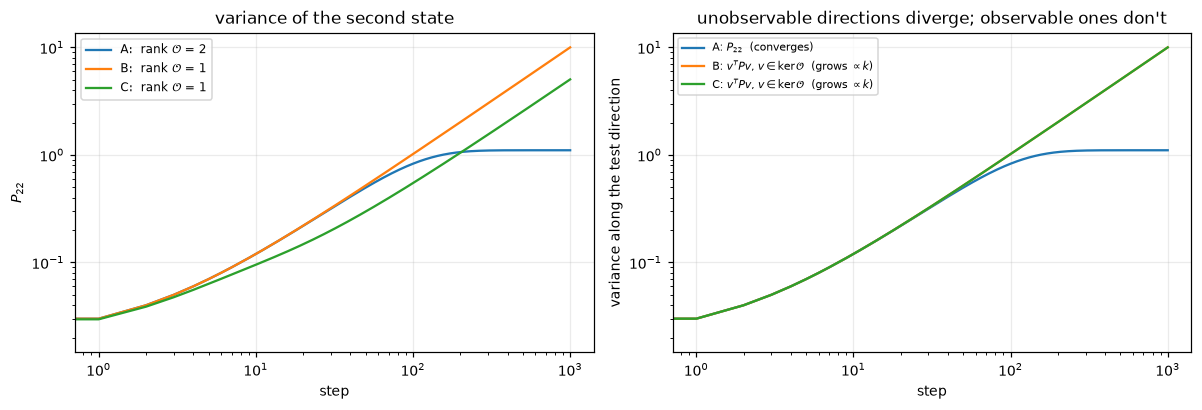

A: variance along the test direction 0.020 -> 1.105 -> 1.106   (converged)
B: variance along the test direction 0.020 -> 5.020 -> 10.010   (DIVERGING, exactly k*q)
C: variance along the test direction 0.020 -> 5.020 -> 10.010   (DIVERGING, exactly k*q)


In [33]:
# The covariance recursion needs no data -- so we can just *ask* what happens.
# Start CONFIDENT (small P0) so that any growth is unmistakably the filter losing ground.
Qw, Rw, P0w, steps = 1e-2*np.eye(2), np.array([[1.0]]), 1e-2*np.eye(2), 1000

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for (name, (F_, H_)), c in zip(cases.items(), ["C0", "C1", "C2"]):
    tag  = name.split(":")[0]
    Ps, _ = riccati(F_, H_, Qw, Rw, P0w, steps)
    O    = observability(F_, H_)
    r    = matrix_rank(O)
    axes[0].loglog(Ps[:, 1, 1], c, label=f"{tag}:  rank $\\mathcal{{O}}$ = {r}")
    if r < 2:
        v = svd(O)[2][-1]                       # the unobservable direction
        axes[1].loglog([v @ P @ v for P in Ps], c,
                       label=f"{tag}: $v^TPv$, $v\\in\\ker\\mathcal{{O}}$  (grows $\\propto k$)")
    else:
        w = np.array([0.0, 1.0])
        axes[1].loglog([w @ P @ w for P in Ps], c, label=f"{tag}: $P_{{22}}$  (converges)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("$P_{22}$"); axes[0].legend(fontsize=8)
axes[0].set_title("variance of the second state")
axes[1].set_xlabel("step"); axes[1].set_ylabel("variance along the test direction")
axes[1].legend(fontsize=7, loc="upper left")
axes[1].set_title("unobservable directions diverge; observable ones don't")
plt.tight_layout(); plt.show()

for name, (F_, H_) in cases.items():
    Ps, _ = riccati(F_, H_, Qw, Rw, P0w, steps)
    O = observability(F_, H_)
    v = svd(O)[2][-1] if matrix_rank(O) < 2 else np.array([0.0, 1.0])
    s = np.array([v @ P @ v for P in Ps])
    print(f"{name.split(':')[0]}: variance along the test direction "
          f"{s[0]:.3f} -> {s[len(s)//2]:.3f} -> {s[-1]:.3f}"
          f"   ({'DIVERGING, exactly k*q' if matrix_rank(O) < 2 else 'converged'})")

In [34]:
# Same story told by the information Gramian.
for name, (F_, H_) in cases.items():
    R_ = np.array([[1.0]])
    G  = sum(matrix_power(F_, j).T @ H_.T @ inv(R_) @ H_ @ matrix_power(F_, j) for j in range(2))
    ev = eigh(G)[0]
    singular = ev.min() <= 1e-12 * ev.max()          # relative tolerance, not absolute
    print(f"{name.split(':')[0]}:  Gramian eigenvalues = [{ev[0]:.3e}, {ev[1]:.3e}]   "
          f"cond = {ev.max()/ev.min() if ev.min() > 0 else np.inf:.2e}\n"
          f"    -> {'SINGULAR: infinite variance along ker(O)' if singular else 'nonsingular: every direction is informed'}")

A:  Gramian eigenvalues = [5.000e-05, 2.000e+00]   cond = 4.00e+04
    -> nonsingular: every direction is informed
B:  Gramian eigenvalues = [0.000e+00, 2.000e+00]   cond = inf
    -> SINGULAR: infinite variance along ker(O)
C:  Gramian eigenvalues = [0.000e+00, 4.000e+00]   cond = inf
    -> SINGULAR: infinite variance along ker(O)


Look closely at case A: the smallest Gramian eigenvalue is about $5\times10^{-5}$ — nonzero, so
velocity *is* observable, but only just. Case A is observable **because of $\Delta t$ alone**, and
$\Delta t$ is small. Compare to cases B and C, where the smallest eigenvalue is exactly $0$ and
no amount of data helps.

Case A is the one that matters here: with $F=\begin{bmatrix}1&\Delta t\\0&1\end{bmatrix}$ and
$H=[1,\ 0]$,

$$\mathcal O_2 = \begin{bmatrix}1 & 0\\ 1 & \Delta t\end{bmatrix},\qquad \det = \Delta t \neq 0 .$$

Angular velocity is observable *purely because of the shear in $F$*. Two consecutive angle
measurements pin it down — which is exactly the "$K_2 = P_{21}/S$" story of §6, now stated as a
determinant. Note also that $\det \mathcal O_2 = \Delta t$: at very high sample rates the system is
only *weakly* observable, the Gramian is ill-conditioned, and velocity estimates get noisy. A real
numerical-conditioning consequence of a rank condition.

---
## 9. Cheat sheet

Every object in the filter, and the linear algebra behind it.

| object | what it is | the linear algebra |
|---|---|---|
| $P$ | state covariance | symmetric PSD $\Rightarrow$ quadratic form $\Rightarrow$ ellipsoid; $u^{\mathsf T}Pu$ = variance along $u$ |
| $P=V\Lambda V^{\mathsf T}$ | spectral decomposition | principal axes $V$, half-lengths $\sqrt{\lambda_i}$ |
| $P=AA^{\mathsf T}$ | any factorisation | ellipse $=A\cdot$(unit sphere); $A$ unique up to an orthogonal factor |
| $FPF^{\mathsf T}$ | prediction | **congruence**: preserves symmetry, PSD, inertia; scales volume by $(\det F)^2$ |
| $+Q$ | process noise | adds PSD $\Rightarrow$ inflates in every direction; $qI$ shifts all eigenvalues by $q$ |
| $S=HPH^{\mathsf T}+R$ | innovation covariance | congruence of $P$ into measurement space, plus sensor noise |
| $PH^{\mathsf T}$ | prior–measurement cross-covariance | the **only** direction(s) the correction can move along |
| $K=PH^{\mathsf T}S^{-1}$ | Kalman gain | the coefficient that decorrelates $x$ from $z$; one step of Gram–Schmidt |
| $P^+=P-PH^{\mathsf T}S^{-1}HP$ | posterior covariance | **Schur complement** $M/S$ of the joint covariance; rank-$m$ downdate |
| $M=LDL^{\mathsf T}$ | joint covariance factored | block Gaussian elimination = conditioning |
| $(I-KH)P(I-KH)^{\mathsf T}+KRK^{\mathsf T}$ | Joseph form | quadratic in $K$; completing the square proves $K$ optimal |
| $P^{-1}+H^{\mathsf T}R^{-1}H$ | information update | additive; Woodbury identity links it to the gain form |
| $\begin{bmatrix}L_P^{-1}\\L_R^{-1}H\end{bmatrix}$ | whitened stack | Kalman filter $=$ recursive weighted least squares; $A^{\mathsf T}A=(P^+)^{-1}$ |
| QR of the pre-array | square-root filter | triangularise the factor instead of the matrix; $\operatorname{cond}(L)=\sqrt{\operatorname{cond}(P)}$ |
| $\mathcal O=[H;HF;\dots]$ | observability matrix | $\operatorname{rank}<n$ $\Rightarrow$ variance diverges along $\ker\mathcal O$ |
| $A_{cl}=(I-KH)F$ | error dynamics | $\rho(A_{cl})<1$ $\Rightarrow$ the filter forgets a bad $\hat x_0$ at rate $\rho^k$ |

### One-screen reference implementation

In [35]:
def kalman_filter(Z, x0, P0, F, Q, H, R, joseph=True):
    """A complete linear Kalman filter. Two operations, alternated."""
    x, P = np.asarray(x0, float), np.asarray(P0, float)
    I    = np.eye(len(x))
    X, PS = [], []
    for z in np.atleast_2d(np.asarray(Z, float).reshape(len(Z), -1)):
        # -- predict: congruence + sum -------------------------------------
        x = F @ x
        P = sym(F @ P @ F.T + Q)
        # -- update: Schur complement --------------------------------------
        y = z - H @ x                            # innovation
        S = H @ P @ H.T + R                      # innovation covariance
        K = solve(S.T, (P @ H.T).T).T            # P H^T S^-1
        x = x + K @ y
        P = sym((I - K @ H) @ P @ (I - K @ H).T + K @ R @ K.T) if joseph \
            else sym((I - K @ H) @ P)
        X.append(x.copy()); PS.append(P.copy())
    return np.array(X), np.array(PS)

Xf, Pf = kalman_filter(Z, [Z[0], 0.0], np.diag([50.**2, 500.**2]), F7, Q7, H7, R7)
print("matches run_kf?", np.allclose(Xf, res["x"], atol=1e-9))
print("final state:", Xf[-1], "   final P:\n", Pf[-1])

matches run_kf? True
final state: [76.422 11.417]    final P:
 [[  1.009   8.867]
 [  8.867 163.153]]


---
## 10. Exercises

Work these in new cells — every one is answerable with the tools above.

1. **Sequential = batch.** Take $H=\begin{bmatrix}1&0\\0&1\end{bmatrix}$, $R=\operatorname{diag}(r_1,r_2)$.
   Update once with both rows, then redo it as two scalar updates applied one after the other.
   Show they agree. *Why does this work, and where exactly does it break if $R$ is not diagonal?*
   (Hint: information adds — and $H^{\mathsf T}R^{-1}H$ splits as a sum only when $R^{-1}$ is block diagonal.
   For correlated $R$, whiten first: $L_R^{-1}z$.)

2. **A perfect sensor.** Let $R\to 0$ with $H=[1,0]$. Compute $K$ and $P^+$. Show $P^+$ becomes
   singular with $\operatorname{rank}=n-1$, and that $HP^+H^{\mathsf T}=0$ — the posterior lives exactly on
   the affine subspace $\{x: Hx=z\}$. Conditioning on a noiseless measurement is *orthogonal projection*
   onto that subspace (in the $P^{-1}$ inner product). Verify the projection claim numerically.

3. **Order-independence.** Fuse three sensors in all $3!$ orders and confirm you get the same posterior.
   Which of the four forms in §5 makes this *obvious* rather than merely true?

4. **A redundant sensor.** Set $H=\begin{bmatrix}1&0\\1&0\end{bmatrix}$ (the same quantity twice).
   What is $\operatorname{rank}(H^{\mathsf T}R^{-1}H)$? Compare $P^+$ against a single measurement with
   variance $r/2$. Now make $S$ singular by setting $R=0$ and watch `inv(S)` blow up — this is the
   classic way a filter dies in the field.

5. **Anisotropic $Q$.** Use $Q = \sigma^2 gg^{\mathsf T}$ with $g=[\Delta t^2/2,\ \Delta t]^{\mathsf T}$
   (rank 1: a single acceleration disturbance). Confirm the prediction inflates the ellipse only along
   $g$: $u^{\mathsf T}Qu = 0$ for every $u \perp g$. How does that compare with the integrated $Q$ used in §7?

6. **Break observability.** Add a constant sensor bias as a third state,
   $x = [\theta,\omega,b]^{\mathsf T}$ with $H = [1,0,1]$ and a bias that does not move ($F_{33}=1$).
   Compute $\operatorname{rank}\mathcal O_3$. Is the bias observable? Now give the bias a slow random
   walk, or add a second sensor with no bias, and recheck. (This is *the* recurring failure mode in
   IMU-based biomechanics.)

7. **Smoothing.** The RTS smoother runs backwards with
   $J_k = P_k F^{\mathsf T}(P^-_{k+1})^{-1}$. Note the shape: it is a Kalman gain with the roles of the
   two Gaussians swapped. Implement it on §7's data and show the smoothed $\pm2\sigma$ band is
   strictly narrower — a second conditioning step can only remove uncertainty.

---
## 11. Where the EKF picks up

Your folder says `EKF_biomecanico`, so: **the linear algebra above does not change at all.**

For a nonlinear system $x_k = f(x_{k-1})$, $z_k = h(x_k)$, the EKF replaces the two constant matrices
by Jacobians evaluated at the current estimate:

$$F_k = \left.\frac{\partial f}{\partial x}\right|_{\hat x_{k-1}},
\qquad
H_k = \left.\frac{\partial h}{\partial x}\right|_{\hat x^-_{k}} .$$

Then $P^- = F_kPF_k^{\mathsf T}+Q$ and $K=P^-H_k^{\mathsf T}S^{-1}$ — character for character the same
expressions. Only two things differ:

* **The mean propagates through the nonlinear function**, $\hat x^- = f(\hat x)$, not $F\hat x$.
  The covariance still propagates through the *linearisation*. That mismatch is the entire error budget of an EKF.
* **$F_k$ and $H_k$ change every step**, so nothing is time-invariant any more: no DARE, no constant
  $K_\infty$, and observability becomes a *local* rank condition on $[H_k; H_{k+1}F_k; \dots]$ that can
  come and go as the limb moves through its range.

Practically, everything in this notebook still applies, and three items apply *harder*: use the
**Joseph form** or a **square-root filter** (§5.4) because repeated relinearisation is where $P$ loses
positive-definiteness; check **NIS whiteness** (§7) because a broken Jacobian shows up there first;
and check the **local observability rank** (§8) at several poses, not just one — a joint model that is
observable at $30^\circ$ of flexion may not be at full extension.